# Project: Machine Learning: Personal Loan Campaign

### Problem Statement

Write the problem statement and objectives here


## Context
AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

## Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

### Data Dictionary

* ID: Customer ID
* Age: Customer’s age in completed years
* Experience: # years of professional experience
* Income: Annual income of the customer (in thousand dollars)
* ZIP Code: Home Address ZIP code.
* Family: The family size of the customer
* CCAvg: Average spending on credit cards per month (in thousand dollars)
* Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* Mortgage: Value of house mortgage if any. (in thousand dollars)
* Personal_Loan: Did this customer accept the personal loan offered in the last campaign?
* Securities_Account: Does the customer have a securities account with the bank?
* CD_Account: Does the customer have a certificate of deposit (CD) account with the bank?
* Online: Do customers use Internet banking facilities?
* CreditCard: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

Installing & importing necessary libraries

In [1]:
# !pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q

### Let us start by importing the required libraries

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Metrics
from sklearn.metrics import (
    recall_score,
    precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
)

import warnings

warnings.filterwarnings("ignore")

Understanding the structure of the data

In [3]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Write your code here to read the data
# Used vs code to complete this project.
loan_campaign_df = pd.read_csv("Loan_Modelling.csv")
df = loan_campaign_df.copy()

View first and last 5 rows of the dataset

In [5]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


Understand the shape of the dataset

In [7]:
df.shape

(5000, 14)

The dataset has 5000 rows & 14 columns.

In [8]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


#### Observations:
* The dataset contains both numerical and categorical variables.
* There are no null values in the dataset.

In [9]:
# # checking for null values
# df.isnull().sum()
# # Droping ID column
# df.drop('ID', axis=1, inplace=True)

#### Observations:
* The dataset contains no missing values.
* We can drop this column as it does not provide any useful information for analysis.

In [10]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


#### Observations:
* Age: 
    * The age of the customers ranges from 26 to 73 years, with a mean age of around 45 years. 
    * This indicates that the customer base is relatively mature, which may    influence their financial decisions and preferences for personal loans.
* Experience: 
    * The years of professional experience among customers range from 0 to 47 years, with an average of around 20 years. 
    * This suggests that many customers have significant work experience, which could impact their financial stability and likelihood of purchasing personal loans. 
    * Some customers have experience of more than 40 years.
* Income: 
    * The annual income of customers varies widely, ranging from $8,000 to $224,000, with an average income of around $73,000. 
    * This indicates a diverse customer base in terms of financial capacity, which may affect their ability to afford personal loans and their interest in such products.
* CCAvg: 
    * The average spending on credit cards per month ranges from $0 to $10,000, with a mean of around $1,930. 
    * 50% of the customers have CCAvg less than 1.5
* Mortgage:
    * Average mortgage value of house of customers is 56k dollars.
    * Some customers have mortgage value of more than 600k dollars.
    * Some customers have not mortgage their house but there are many outliers.
* Family:
    * Most of the customers are live alone((~28%)
    * Second most are the ones with one dependent on them(~27%)

Dropping Columns
 * Let's drop ID column before we proceed with the analysis as it does not provide any useful information for our analysis.

In [11]:
df = df.drop("ID", axis=1)

### Data Preprocessing

In [12]:
df["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [13]:
# Checking for experience < 0
df[df["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

Assuming the negative values in Experience column are due to data entry errors, we can replace them with the absolute values to correct the data. This way, we can retain the information about the years of experience without losing any data points.

In [14]:
df["Experience"].replace(-1, 1, inplace=True)
df["Experience"].replace(-2, 2, inplace=True)
df["Experience"].replace(-3, 3, inplace=True)

In [15]:
df["Education"].unique()

array([1, 2, 3])

Updating Education column values

In [16]:
df["Education"].replace(1, "Undergraduate", inplace=True)
df["Education"].replace(2, "Graduate", inplace=True)
df["Education"].replace(3, "Professional", inplace=True)

Feature Engineering

In [17]:
df["ZIPCode"].nunique()

467

* There are 467 uniques values in zip code.
* Try to group them based on first 2 digits to reduce no of unique values in ZIPCode column.

In [18]:
df["ZIPCode"] = df["ZIPCode"].astype(str)
df["ZIPCode"] = df["ZIPCode"].str[0:2]
df["ZIPCode"] = df["ZIPCode"].astype("category")

In [19]:
## Converting the date type of categorical features to 'category'
cat_col = [
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "ZIPCode",
]
df[cat_col] = df[cat_col].astype("category")

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

### **Note**: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the <a href = #link1>appendix section</a>.

### Univariate Analysis

In [20]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    (
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
        if bins
        else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [21]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on Mortgage

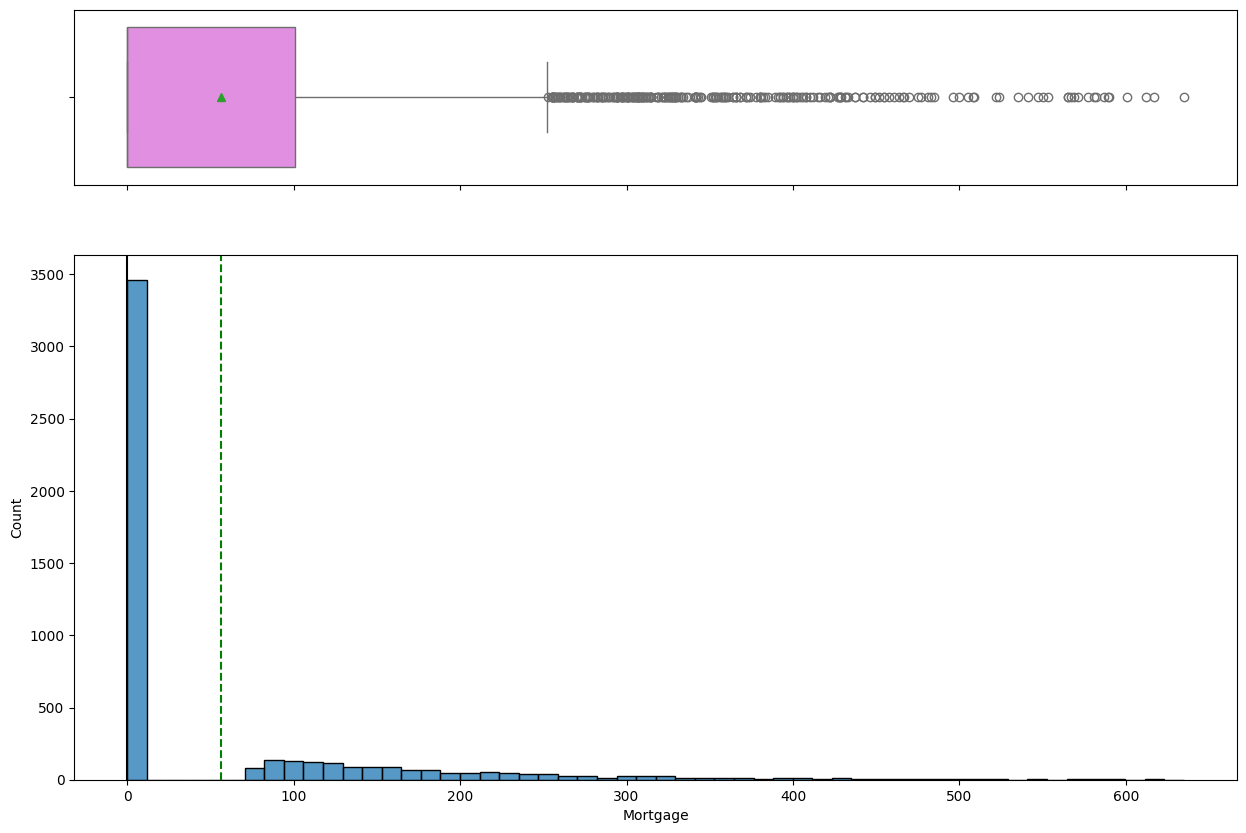

In [22]:
histogram_boxplot(df, "Mortgage")

* Most customers have not mortgaged their house but there are many outliers.
* Some customers have mortgage value of more than 600k dollars.
* Such customers can be potential customers who require a personal loan

#### Observation on CreditCard

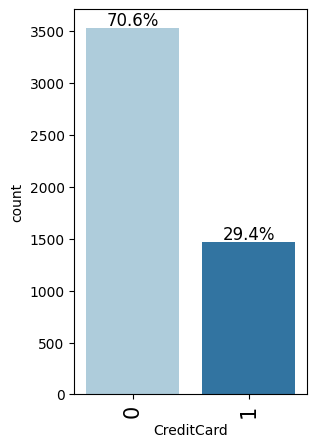

In [23]:
labeled_barplot(df, "CreditCard", perc=True)

* Approximately 70% of customers do not have a credit card issued by any other bank.

####  Observations on Income

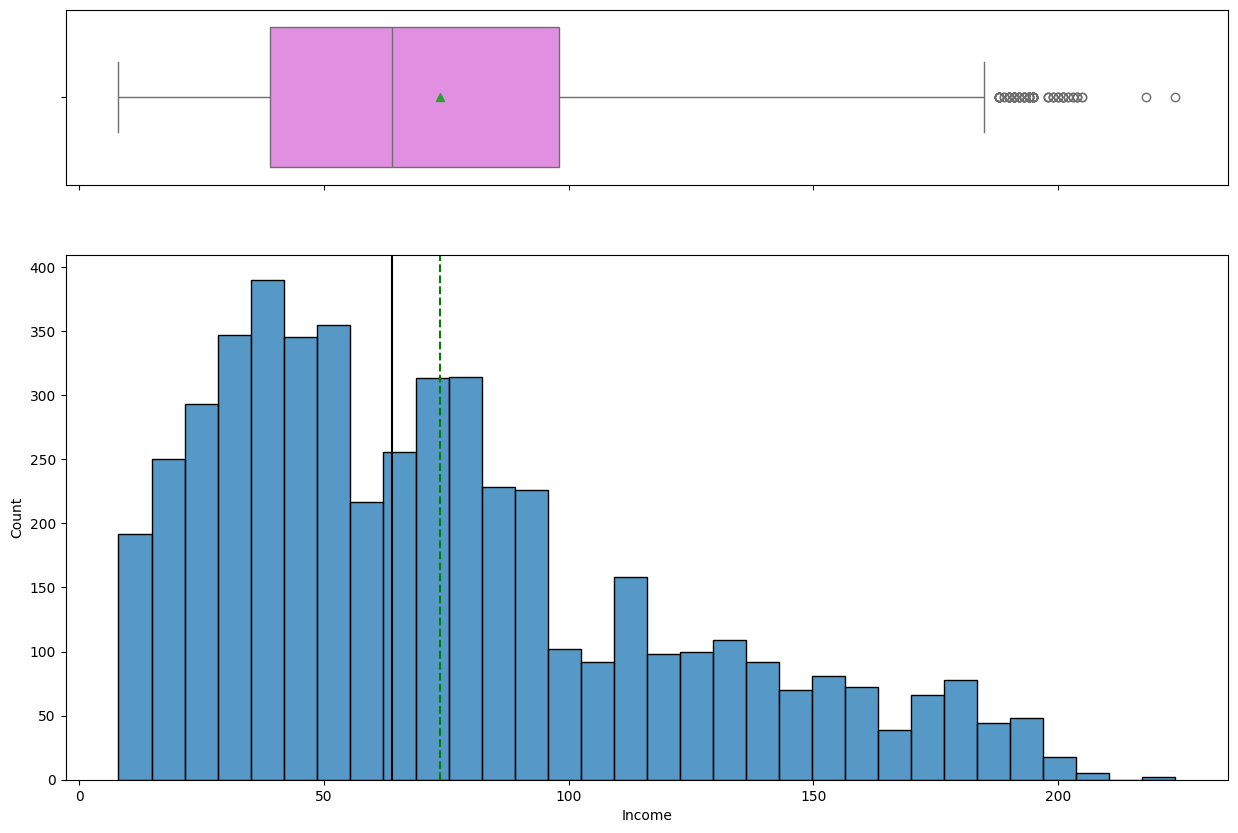

In [24]:
histogram_boxplot(df, "Income")

* The distribution of Income is skewed to right.
* Some customers have an Income bove 200k dollars.
* 50% of the cutomers have income less than 64k dollars.

### Bivariate Analysis

In [25]:
def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [26]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

#### Correlation Check

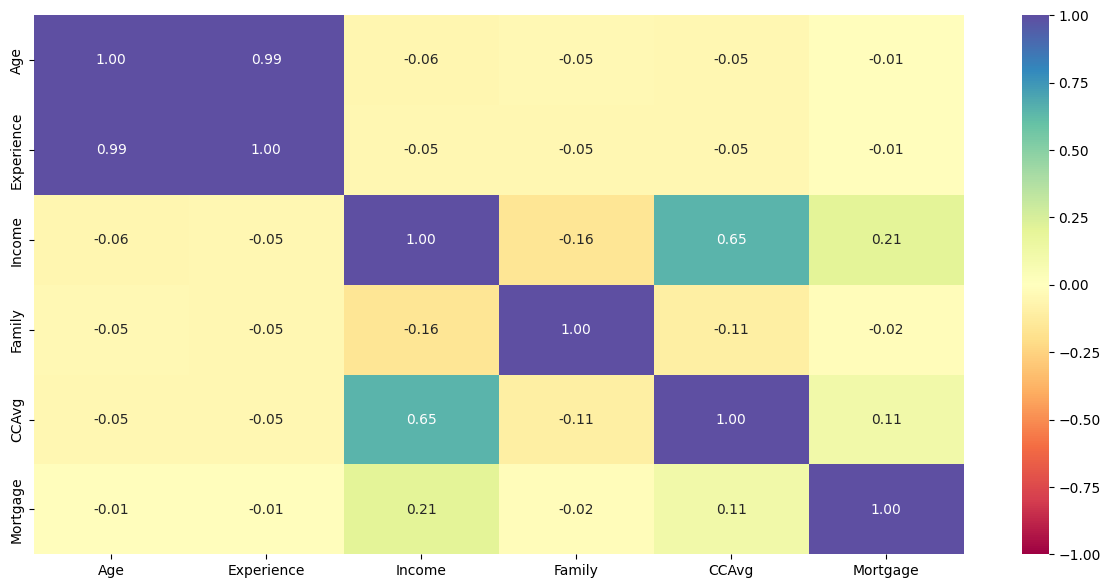

In [27]:
# Correlation Plot
plt.figure(figsize=(15, 7))
sns.heatmap(
    df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* Age & Experience heave perfect correlation hence one of these variables can be dropped whilebuilding as they will provide the same information to the model.
* Income & CCAvg have a moderate correlation which makes sense as the income increases the spendings might also increase.
* Family has a negative correlation with income, which is quite surprising as family size increases the income of the family decreases. But this correlation is not too strong to conclude.

#### Personal_Loan vs Education

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
Professional   1296  205  1501
Graduate       1221  182  1403
Undergraduate  2003   93  2096
------------------------------------------------------------------------------------------------------------------------


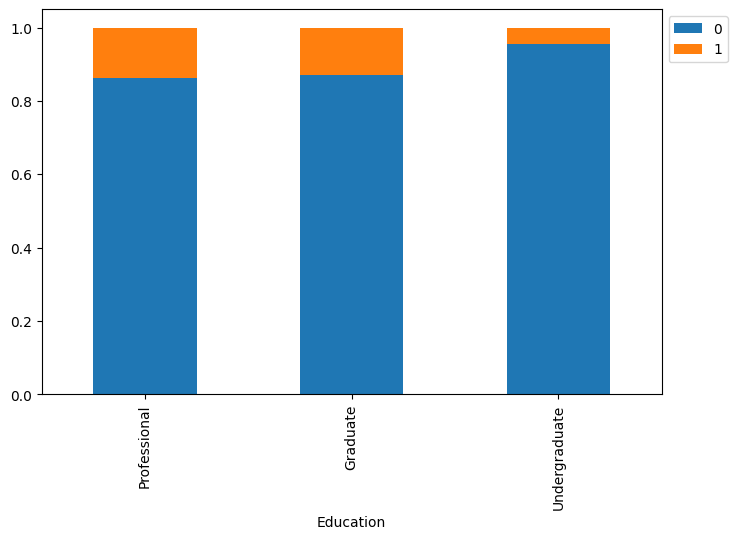

In [28]:
stacked_barplot(df, "Education", "Personal_Loan")

* -15% of the customers who have done advanced/professional studies are the ones that require a personal loan.
* Undergraduates have the least requirement of personal loans.

#### Personal Loan vs Age

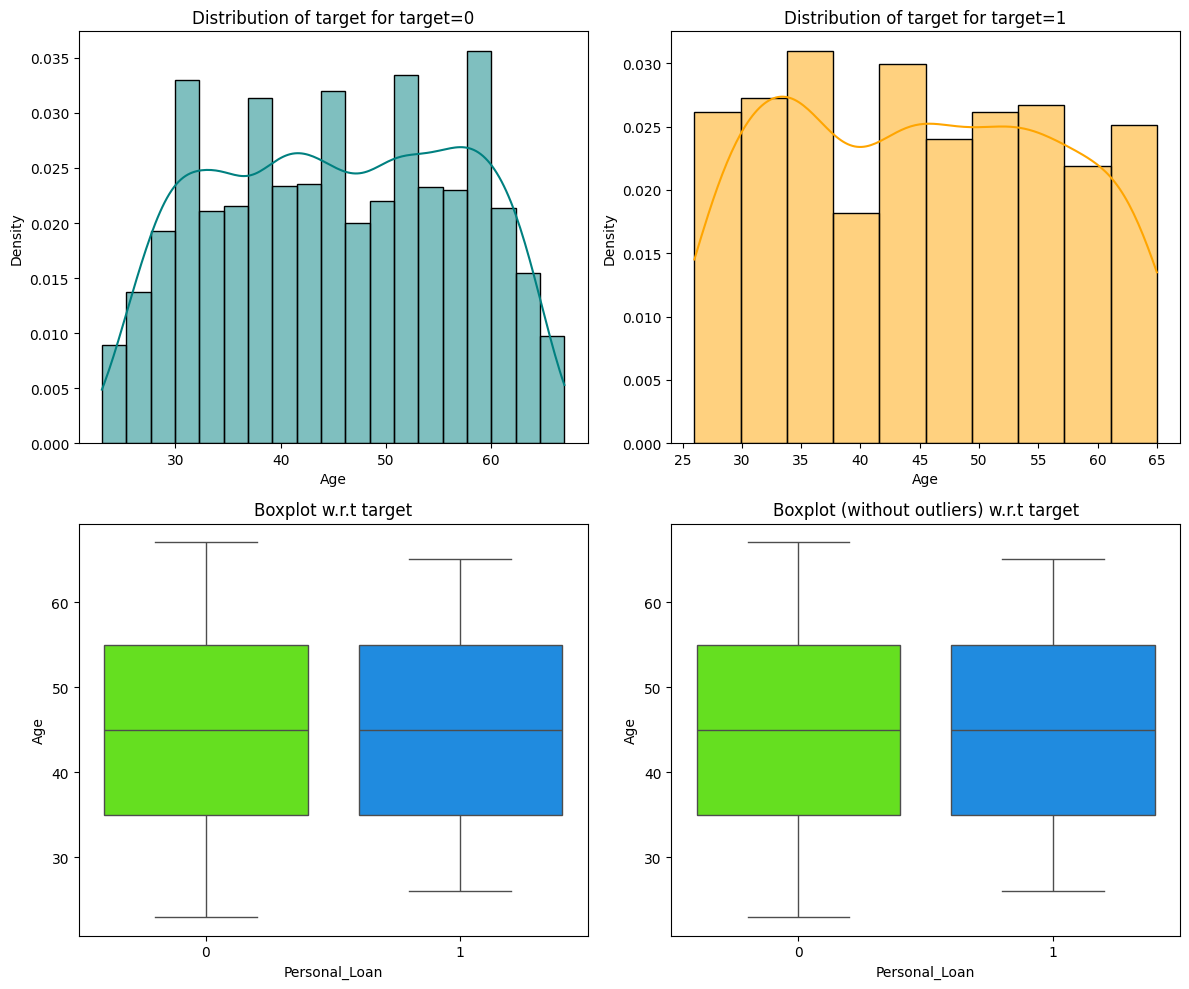

In [29]:
distribution_plot_wrt_target(df, "Age", "Personal_Loan")

* The customers who have the requirement of a Personal Loan have a wider range then the ones who do not require a Personal Loan.

#### Personal_Loan vs Income

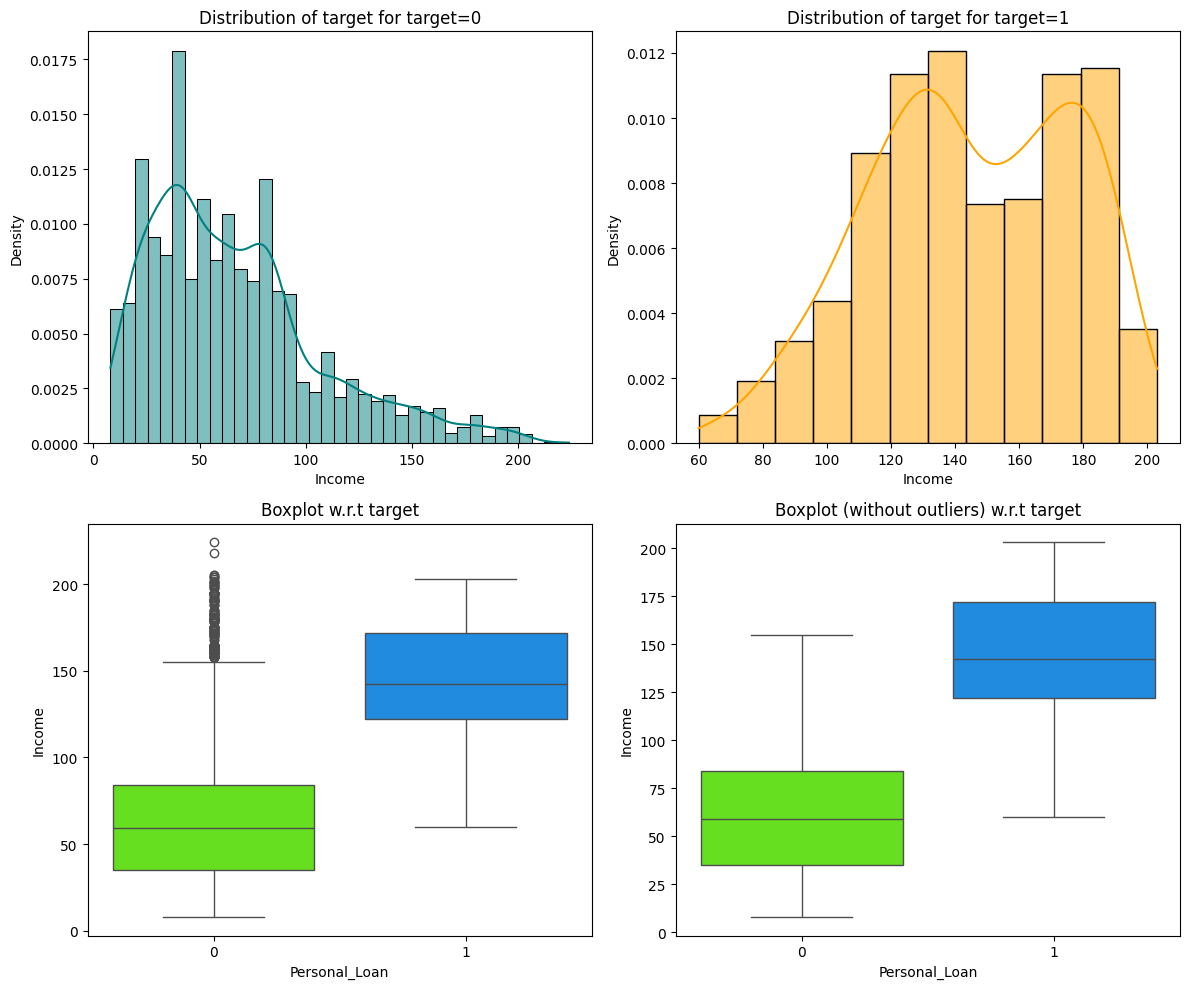

In [30]:
distribution_plot_wrt_target(df, "Income", "Personal_Loan")

* Those customers who have an income higher than 90k-100k dollars are potential cutomers who will take the Personal Loan.
* Income seems to be a signigicant predictor as it provides a good separation between two classes.

#### Outlier Detection

In [31]:
Q1 = df.select_dtypes(include=["float64", "int64"]).quantile(0.25)
Q3 = df.select_dtypes(include=["float64", "int64"]).quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [32]:
(
    (df.select_dtypes(include=["float64", "int64"]) < lower)
    | (df.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(df) * 100

Age           0.00
Experience    0.00
Income        1.92
Family        0.00
CCAvg         6.48
Mortgage      5.82
dtype: float64

* We will not be treating the outliers as in a real case scenario (in income, mortgage value, Average spending on the credit card, etc) and we would wnat our model to learn the underlying pattern for such customers.

#### Data Preparation for Modeling

* We have 6 categorical independent variables but 4 of them are binary, so we'll have the smae results with them even after creating dummies.
* So we will only make dummies for ZIPCOde & Education.

In [33]:
X = df.drop(["Personal_Loan", "Experience"], axis=1)
Y = df["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [34]:
print("Shape of Training set: ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set:  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**
- Predicting a customer will take the personal loan, but in reality, the customer will not take the personal loan - Loss of resources
- Predicting a customer will not take the personal loan, but in reality, the customer was going to take the personal loan - Loss of opportunity

**Which case is more important?**

- Losing a potential customer by predicting that the customer will not be taking the personal loan, but in reality, the customer was going to take the personal loan.

**How to reduce the losses?**

Bank would want Recall to be maximized, the greater the Recall higher the chances of minimizing false negative, Hence, the focus should be on increasing Recall or minimizing the false negatives.

Creating function to calculate evaluation metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

In [35]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [36]:
def confusion_matrix_sklearn(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree (sklearn default)

In [37]:
model0 = DecisionTreeClassifier(criterion="gini", random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Checking model performance on training data

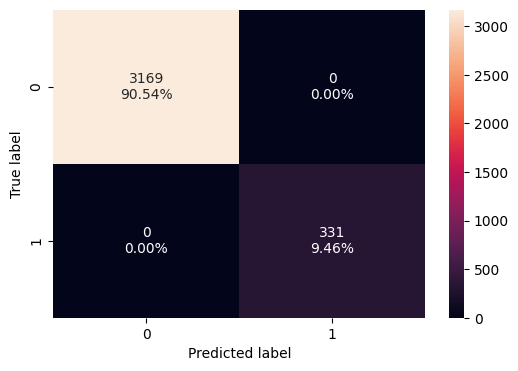

In [38]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [39]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* 0 errors on the training set, each sample has been classified correctly. 
* Model has performed very well on the training set.
* As we know a decision tree will continue to grow and classify each data point correctly, if no restrictions are applied as the trees will learn all the patterns in the training set.

#### Visualizing the decision tree

In [40]:
feature_names = list(X_train.columns)
feature_names

['Age',
 'Income',
 'Family',
 'CCAvg',
 'Mortgage',
 'Securities_Account',
 'CD_Account',
 'Online',
 'CreditCard',
 'ZIPCode_91',
 'ZIPCode_92',
 'ZIPCode_93',
 'ZIPCode_94',
 'ZIPCode_95',
 'ZIPCode_96',
 'Education_Professional',
 'Education_Undergraduate']

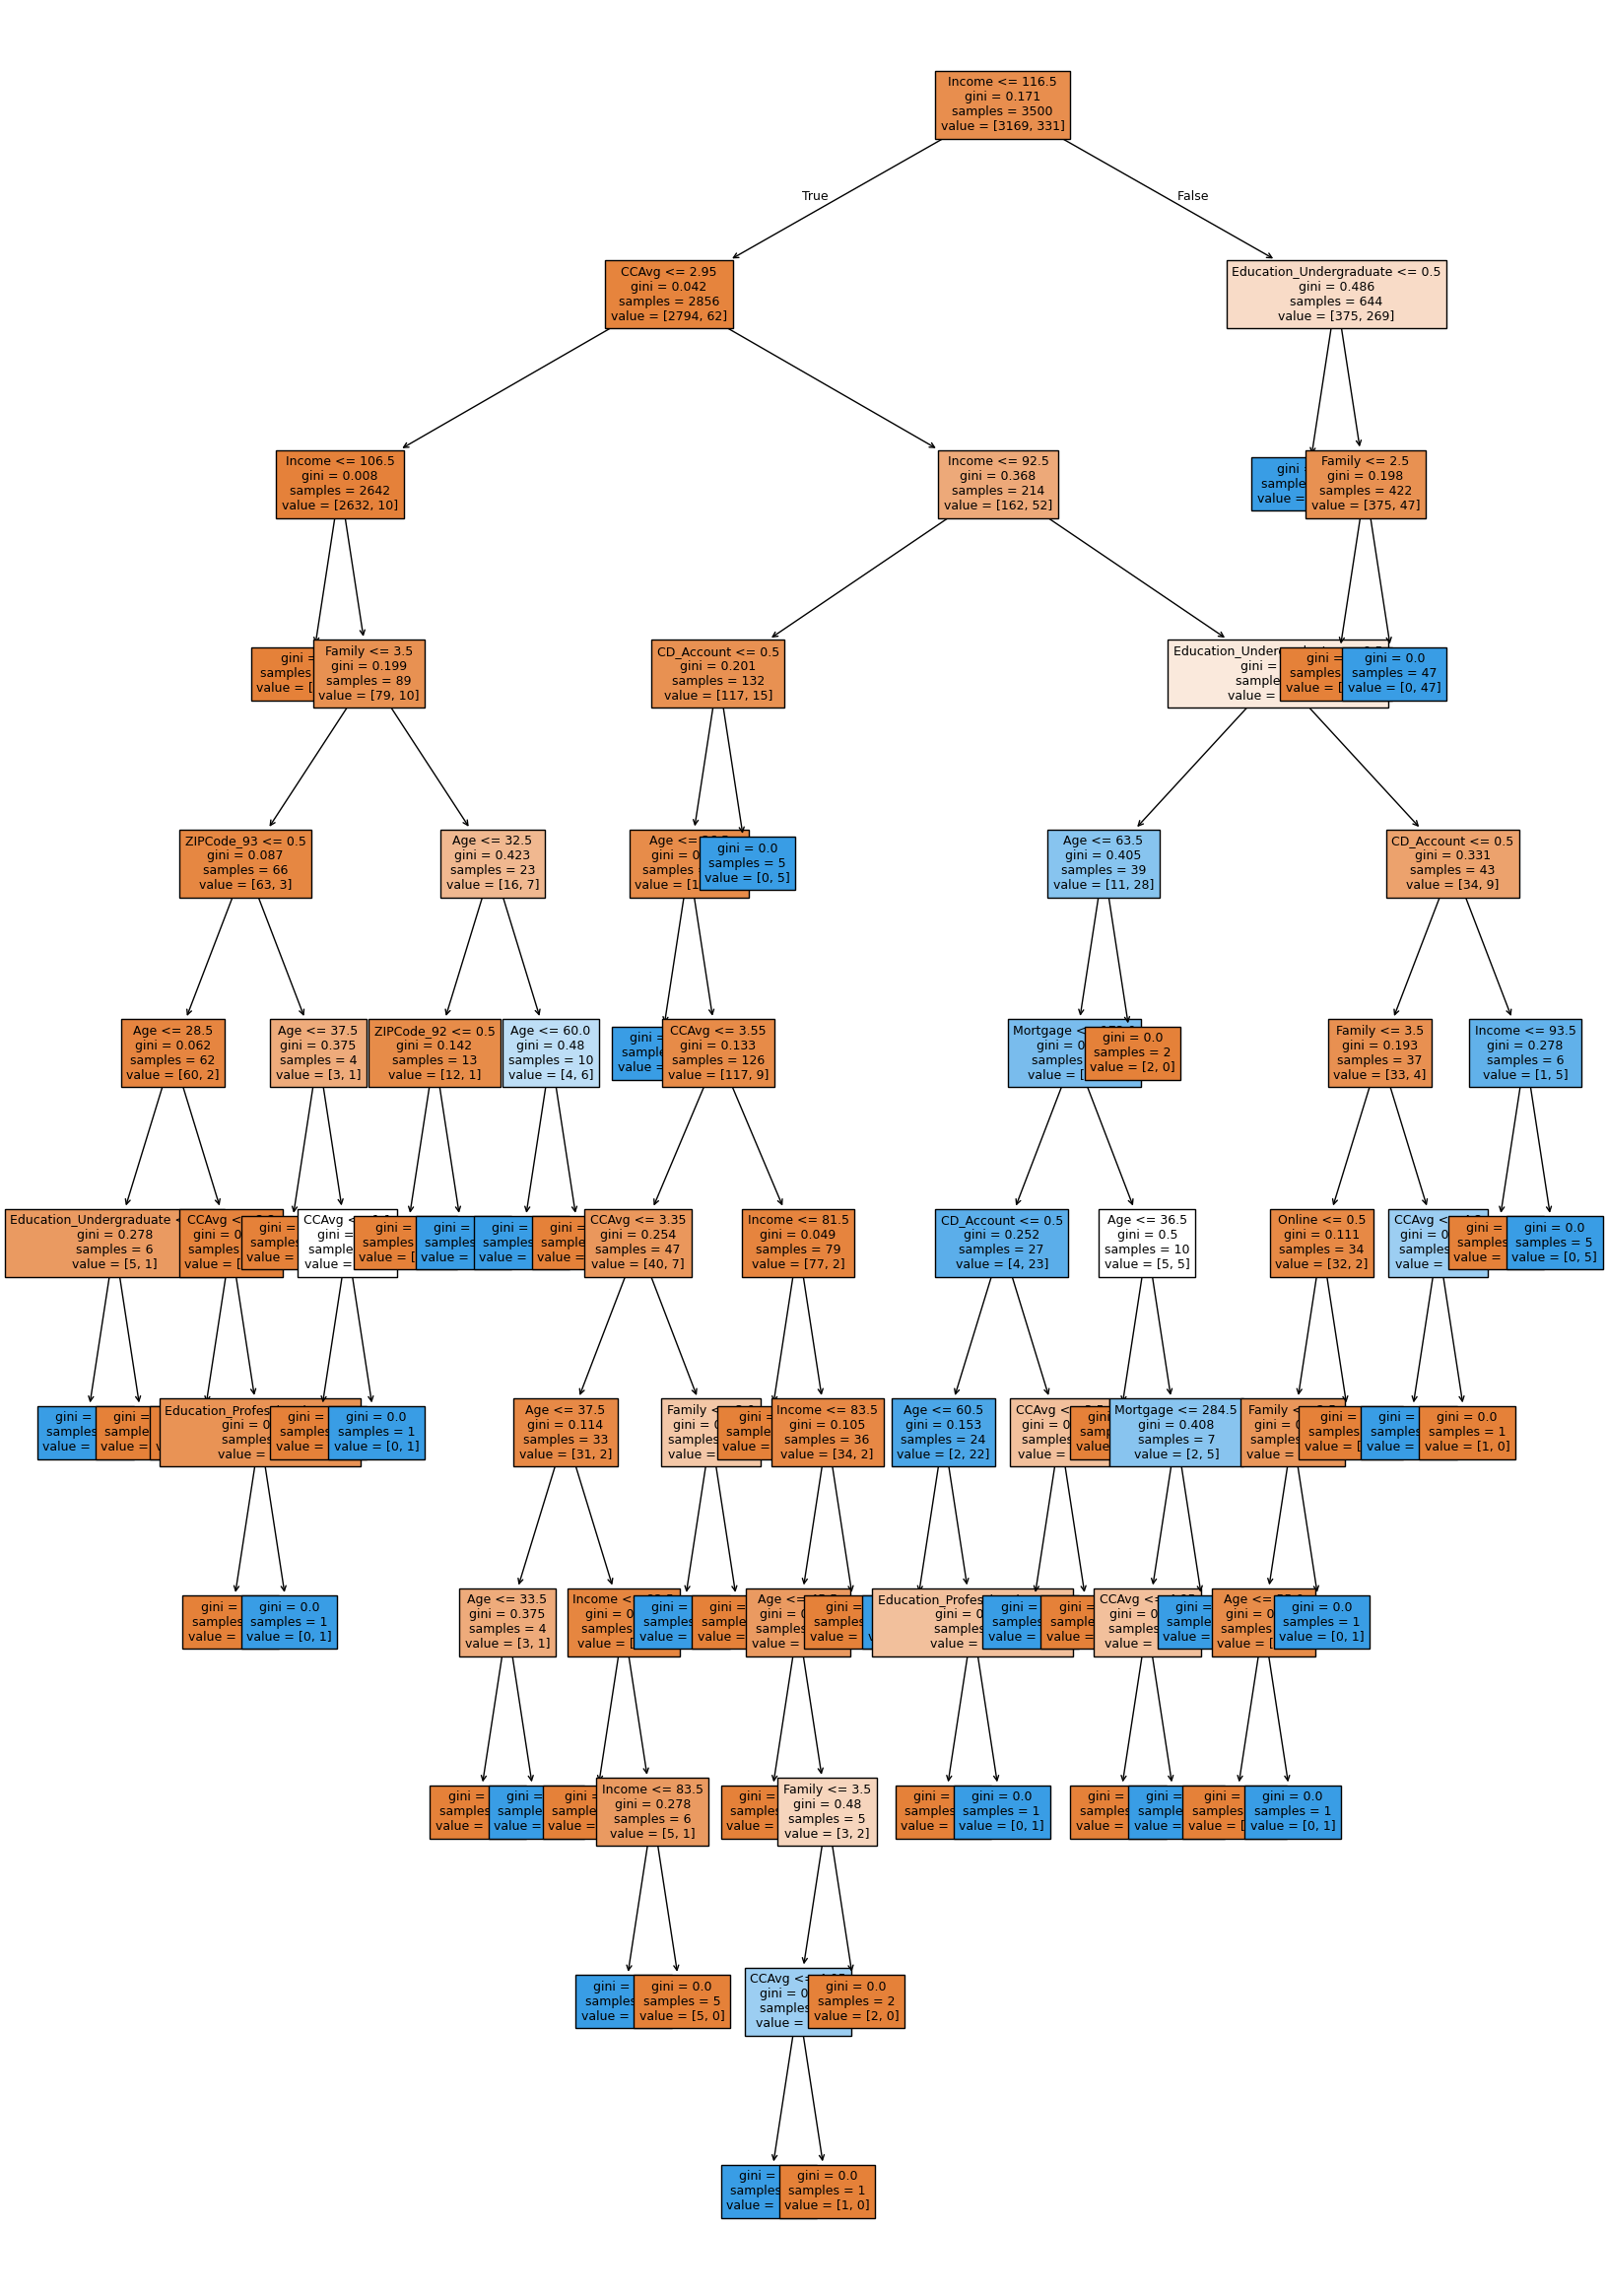

In [41]:
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
    model0,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [42]:
print(tree.export_text(model0, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- ZIPCode_93 <= 0.50
|   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |--- Education_Undergraduate <= 0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- Education_Undergraduate >  0.50
|   |   |   |   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |--- CCAvg <= 2.20
|   |   |   |   |   |   |   |--- weights: [48.00, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  2.20
|   |   |   |   |   |   |   |--- Education_Professional <= 0.50
|   |   |   |   |   |   |   |   |--- weights: [7.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Education_Professional >  0.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- ZIPCode_93

In [43]:
print(
    pd.DataFrame(
        model0.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Education_Undergraduate  0.403732
Income                   0.304761
Family                   0.161717
CCAvg                    0.053107
Age                      0.036035
CD_Account               0.025711
Mortgage                 0.005557
Education_Professional   0.005144
ZIPCode_92               0.003080
ZIPCode_93               0.000594
Online                   0.000561
CreditCard               0.000000
Securities_Account       0.000000
ZIPCode_94               0.000000
ZIPCode_91               0.000000
ZIPCode_96               0.000000
ZIPCode_95               0.000000


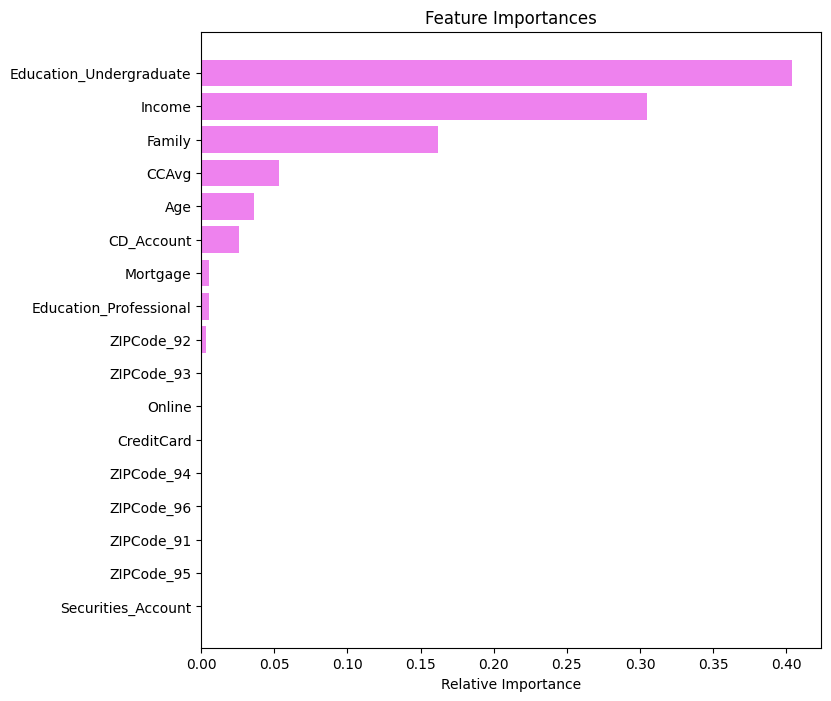

In [44]:
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Education Ungerfraduated is the most important feature followed by income, family and CCAvg.
* The tree above is very complex and difficult to interpret.
* Let's prune the tree, to reduce the complexity.

#### Checking model performance on test data

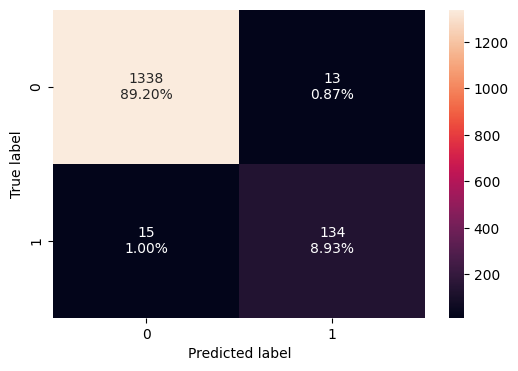

In [45]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [46]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.981333,0.899329,0.911565,0.905405


### Performance imporovement

#### Pre-Pruning

In [47]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float("inf")
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight="balanced",
                random_state=42,
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


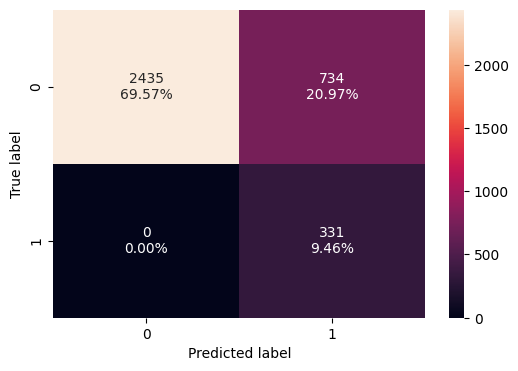

In [48]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [49]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


#### Visualizing the decision tree

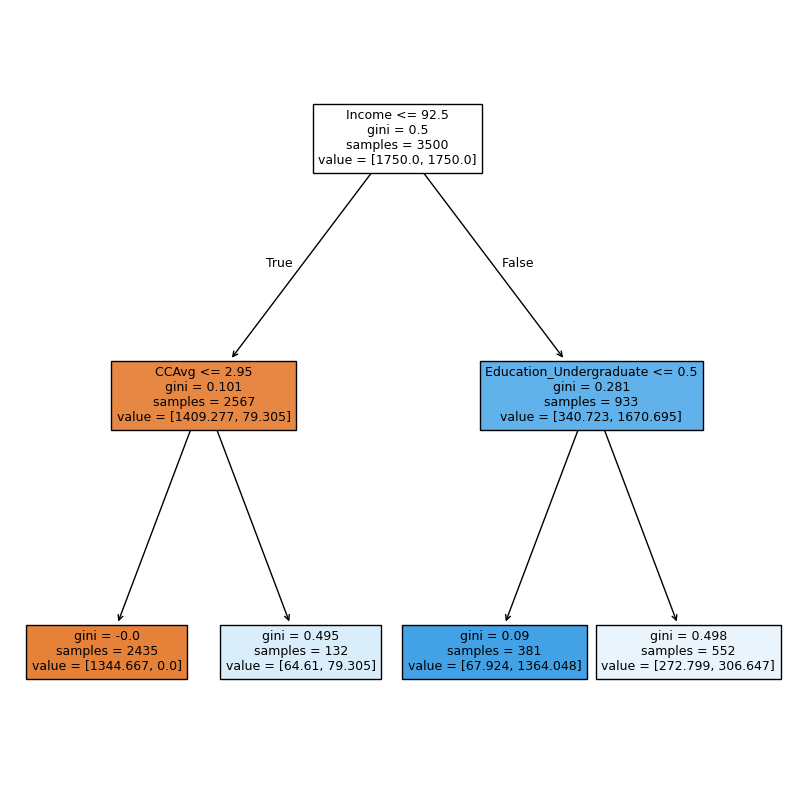

In [50]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [51]:
print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Education_Undergraduate <= 0.50
|   |   |--- weights: [67.92, 1364.05] class: 1
|   |--- Education_Undergraduate >  0.50
|   |   |--- weights: [272.80, 306.65] class: 1



#### Observations
* We can see that the tree has become simpler and more readable.
* The model performance has decreased but a recall of 0.92 is still satisfactory.

In [52]:
print(
    pd.DataFrame(
        model1.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Income                   0.820072
Education_Undergraduate  0.117300
CCAvg                    0.062628
Age                      0.000000
Family                   0.000000
Securities_Account       0.000000
CD_Account               0.000000
Online                   0.000000
Mortgage                 0.000000
CreditCard               0.000000
ZIPCode_91               0.000000
ZIPCode_93               0.000000
ZIPCode_92               0.000000
ZIPCode_94               0.000000
ZIPCode_95               0.000000
ZIPCode_96               0.000000
Education_Professional   0.000000


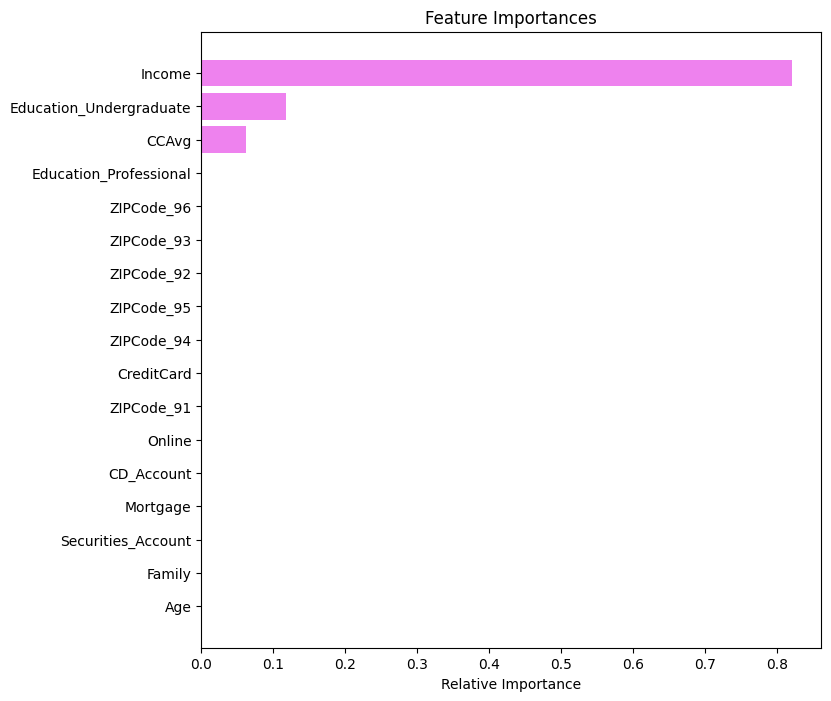

In [53]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Observations
* Online, CreditCard, Securities_Account, ZIPCode have very little importance, Education Under Graduated is most important followed by income, Family and CCAvg.
* People with Income less than 116.5K dollars, CCAvg less than 2.95 and income less than 92.50k dollars have fewer chances of taking the personal loan.
* People having Income more than 116.5K dollars, family size less than or equal to 2 and educational level of undergraduated have less chances of taking the personal loan.
* People having Income more than 116.5K dollars, family size more than 2 and educational level of undergraduated have more chances of taking the personal loan.
* So bank should campaign more on people with higher income, More education and larger family sizes.

#### Checking performance on test data

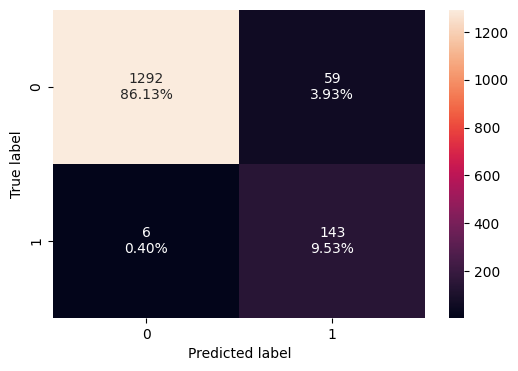

In [54]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [55]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.956667,0.959732,0.707921,0.814815


### Post Pruning

In [56]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [57]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000214,0.000429
2,0.000223,0.001542
3,0.000242,0.002750
4,0.000268,0.003824
5,0.000359,0.004900
6,0.000381,0.005280
7,0.000381,0.005661
8,0.000381,0.006042
9,0.000381,0.006423


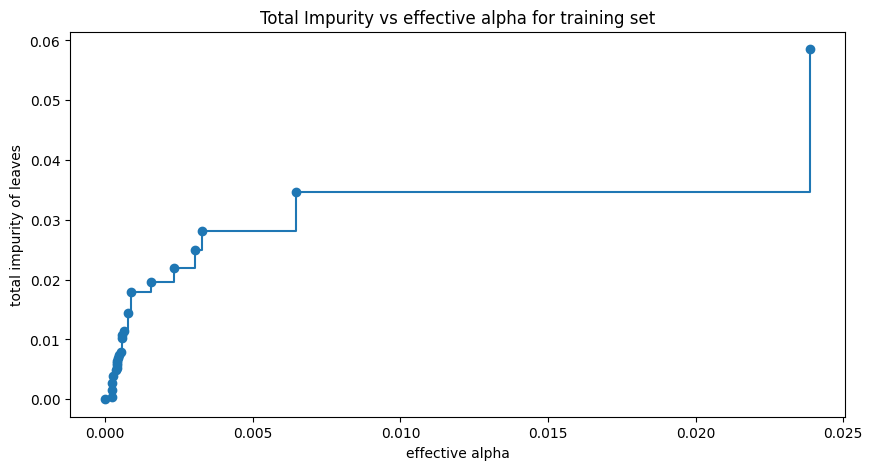

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [59]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.056364969335601575


For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

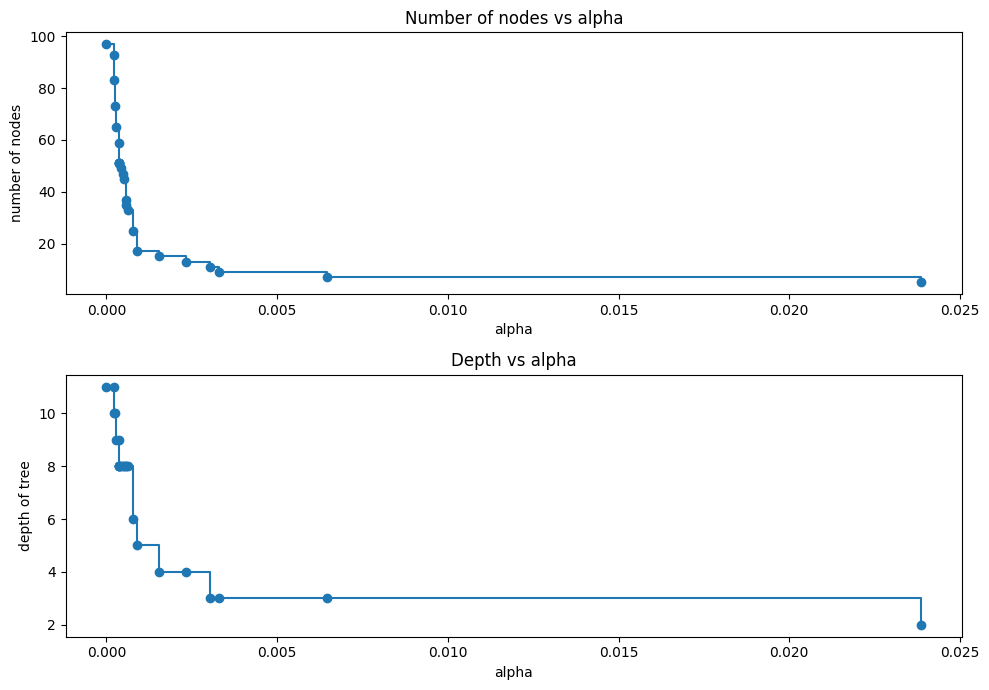

In [60]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#### Recall vs Alpha for training & testing sets

In [61]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

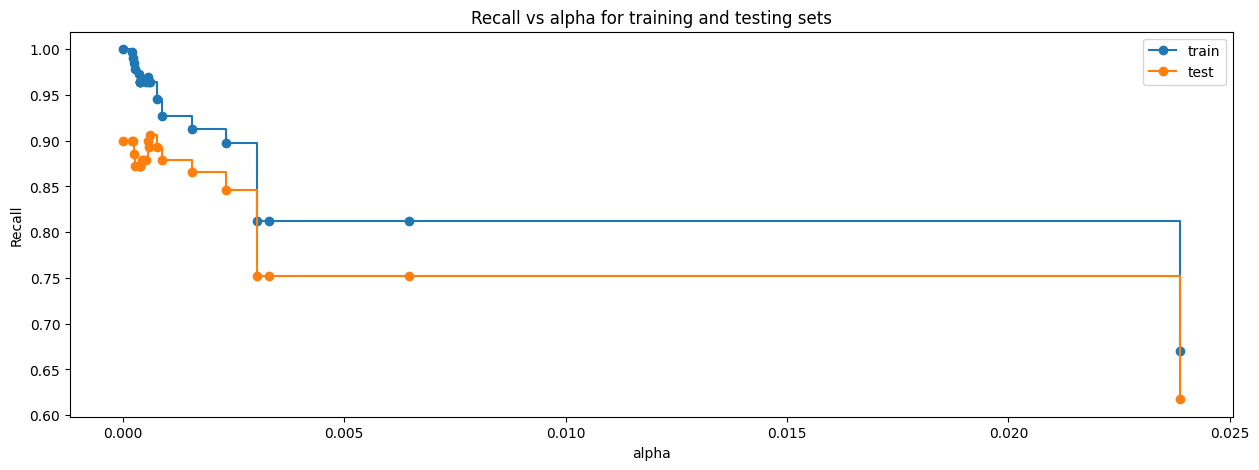

In [62]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [63]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
model2 = best_model
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006209286209286216),
                       random_state=1)


* Post -pruning using ccp alpha returns the same model as the initial model(Tree with no pruning)
* As post pruning model is the same as the initial decision tree model, the performance and feature importance will also be the same.

In [64]:
estimator_2 = DecisionTreeClassifier(
    ccp_alpha=ccp_alpha, class_weight={0: 0.15, 1: 0.85}, random_state=1
)
estimator_2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.056364969335601575),
                       class_weight={0: 0.15, 1: 0.85}, random_state=1)

#### Checking performance on training data

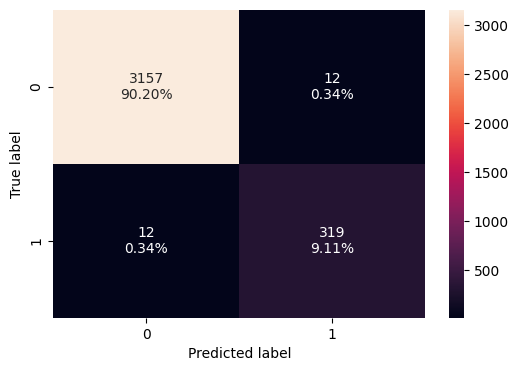

In [65]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [66]:
decision_tree_tune_post_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_post_train

,Accuracy,Recall,Precision,F1
0,0.993143,0.963746,0.963746,0.963746


#### Visualizing the Decision Tree

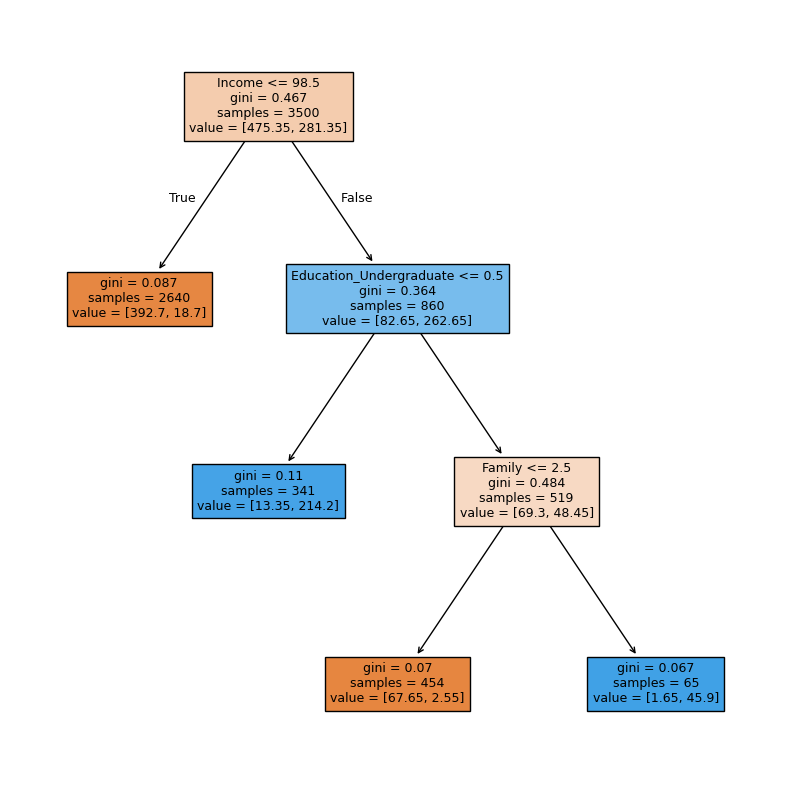

In [67]:
plt.figure(figsize=(10, 10))

out = tree.plot_tree(
    estimator_2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [68]:
print(tree.export_text(estimator_2, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- weights: [392.70, 18.70] class: 0
|--- Income >  98.50
|   |--- Education_Undergraduate <= 0.50
|   |   |--- weights: [13.35, 214.20] class: 1
|   |--- Education_Undergraduate >  0.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [67.65, 2.55] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [1.65, 45.90] class: 1



In [69]:
print(
    pd.DataFrame(
        estimator_2.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Income                   0.674921
Family                   0.171953
Education_Undergraduate  0.153126
Age                      0.000000
CCAvg                    0.000000
Securities_Account       0.000000
CD_Account               0.000000
Online                   0.000000
Mortgage                 0.000000
CreditCard               0.000000
ZIPCode_91               0.000000
ZIPCode_93               0.000000
ZIPCode_92               0.000000
ZIPCode_94               0.000000
ZIPCode_95               0.000000
ZIPCode_96               0.000000
Education_Professional   0.000000


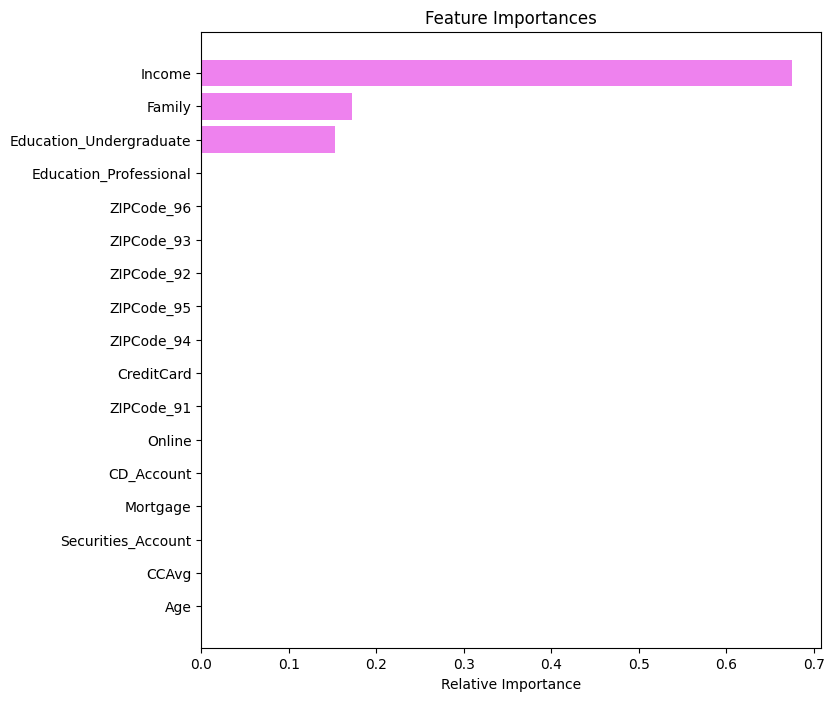

In [70]:
importances = estimator_2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Checking performance on test data

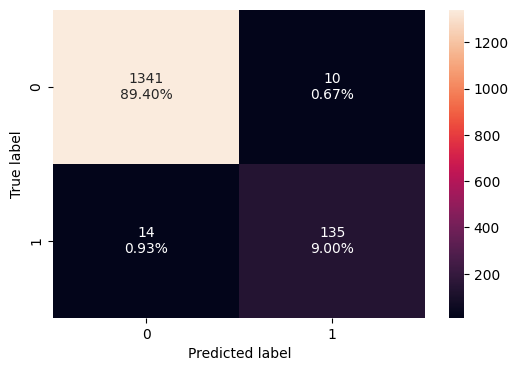

In [71]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [72]:
decision_tree_tune_post_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_post_test

,Accuracy,Recall,Precision,F1
0,0.984,0.90604,0.931034,0.918367


### Model Performance Comparison & Final Model Selection

In [73]:
models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_tune_post_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.790286,0.993143
Recall,1.0,1.000000,0.963746
Precision,1.0,0.310798,0.963746
F1,1.0,0.474212,0.963746


In [74]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_tune_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.981333,0.956667,0.984000
Recall,0.899329,0.959732,0.906040
Precision,0.911565,0.707921,0.931034
F1,0.905405,0.814815,0.918367


### Conclusion
* Overall, the Decision Tree(Pre-Pruning) performs perfectly on the training set and has a recall of 100%, but its recall score on the test set is aroung 96% indicating some overfitting to the traning data,
* Looking at important variables based on Feature importance in Decision Trees
    * Income, CCAvg, CD_Accound, Family, Education are important features for decision making


### Actionable Insights & Business Recommendations

* We have been able to build a predicitve model:
    * that the bank can deploy to identify customers who will be interested in taking a personal loan.
    * that the banck can use to find the key factors that will have an impact on a customer taking a personal loan or not
* Factors that have an imact on Personale_Loan, Income, Family, Education.
* Hgher iincome customers are the chances to take a loan - Customers who are more educated(education level greater than undergraduated) have higher chance of taking a personal loan.
* Size of the family has a positive coreelation with the personal load, as the size of the family increases (generatlly a family size of 3 or more than 3 members) have more chances of taking a personal loan.
* Our analysis showed that ~50% of the customers who have the certificate of deposit with the bank (CD_Account) are the ones that have the requirement of Personal Loan - Bank should target such customers.

## <a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

### Univariate Analysis

#### Observation on Air temperature

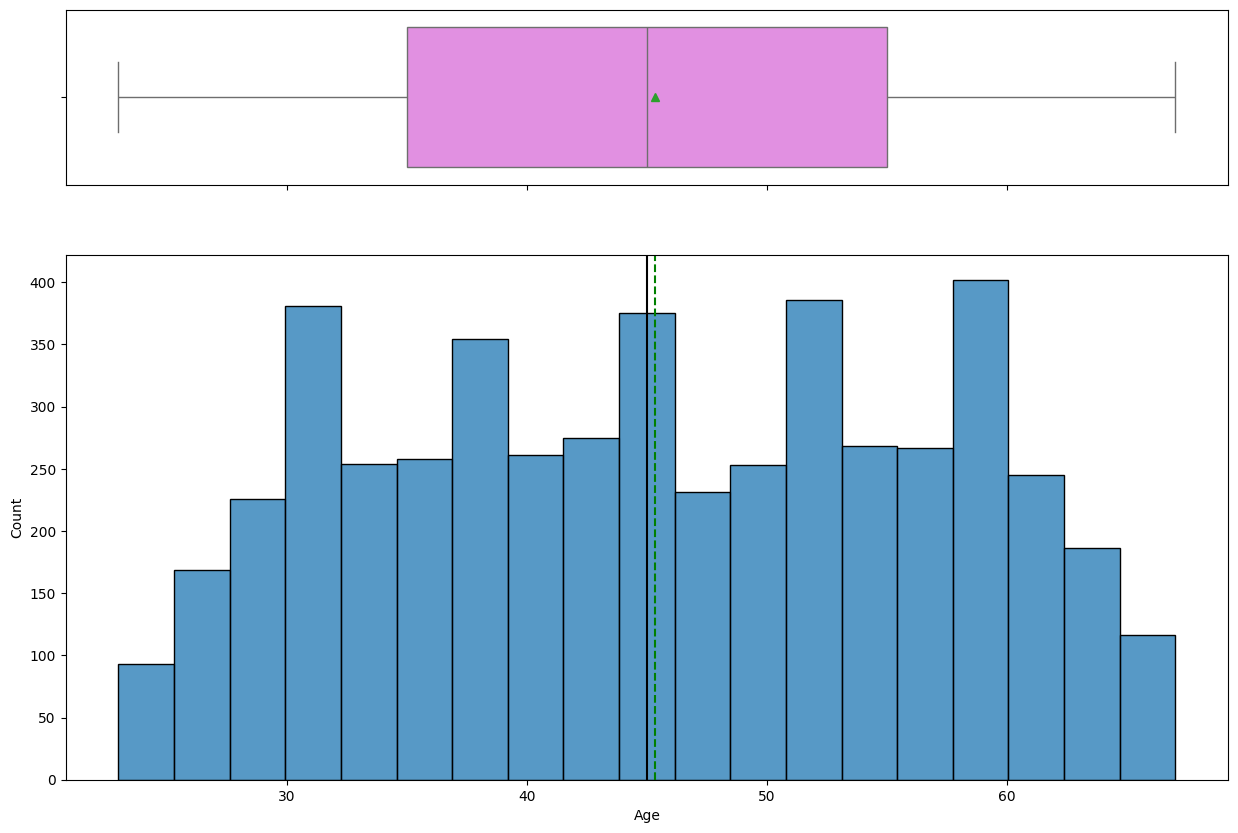

In [75]:
histogram_boxplot(df, "Age")

* Age is concentrated around 35–55, with few customers at extreme young/old ends.
* Distribution is roughly normal/mildly right-skewed.

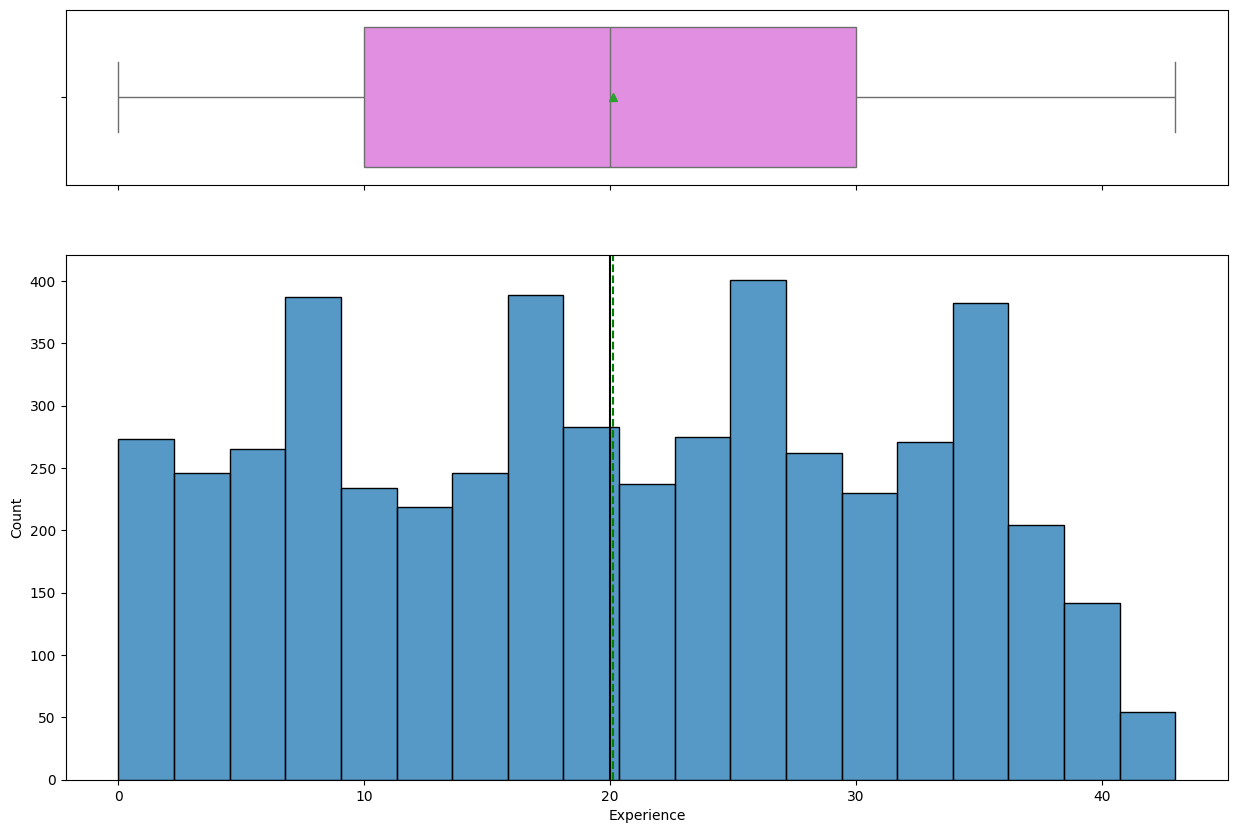

In [76]:
histogram_boxplot(df, "Experience")

* Most customers have 15–30 years of experience.
* After fixing negatives, distribution is similar to age (high correlation), few low-experience values.

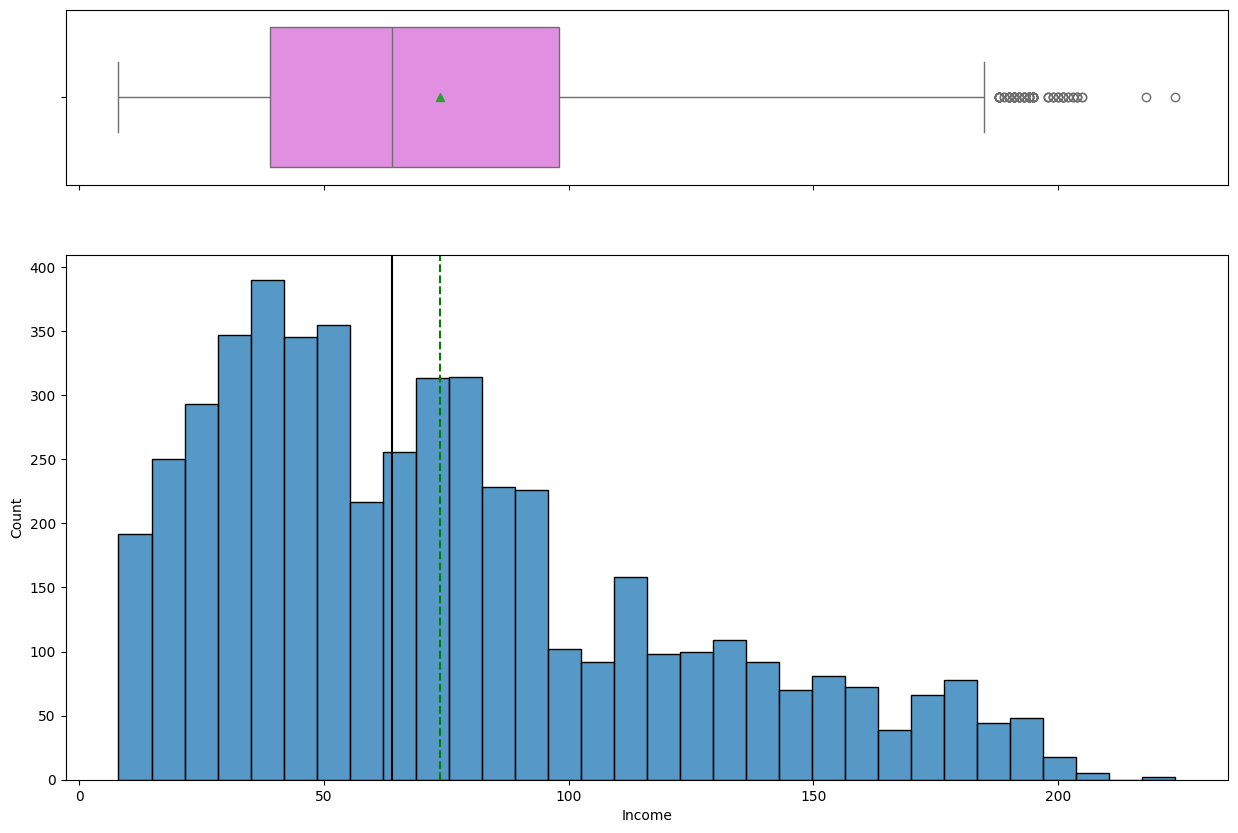

In [77]:
histogram_boxplot(df, "Income")

* Right-skewed; majority under 100K, long tail to 224K.
* Median ~64K (consistent with earlier analysis), high-income outliers present.

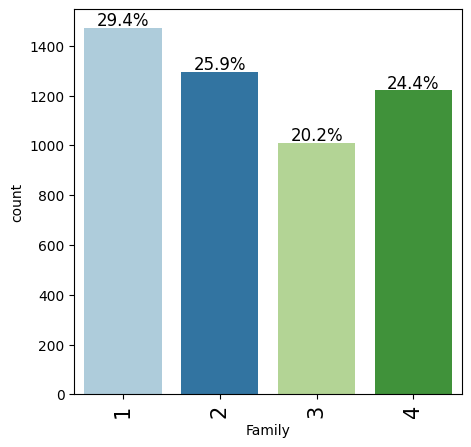

In [78]:
labeled_barplot(df, "Family", perc=True)

* Most customers are 1-2 member families; 3+ less frequent.
* 1-member is highest share, then 2-members.

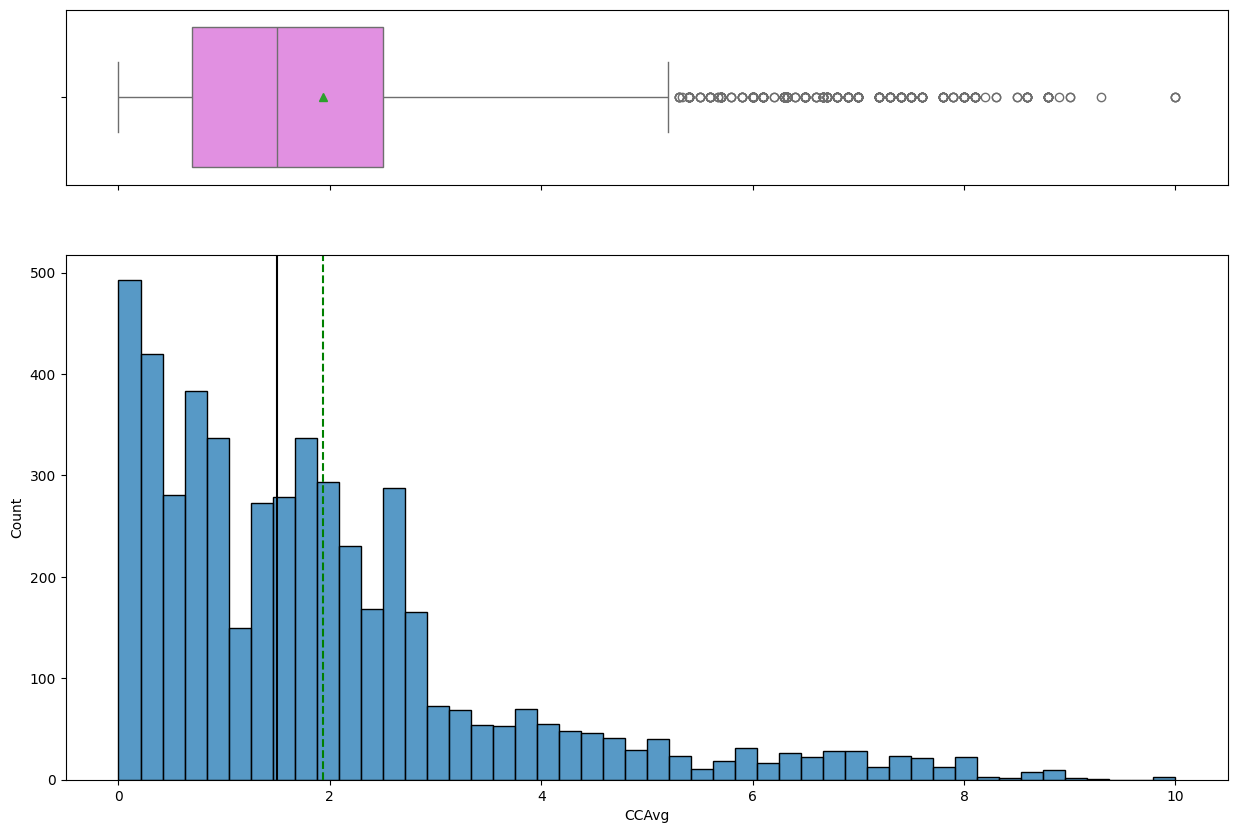

In [79]:
histogram_boxplot(df, "CCAvg")

* Right-skewed with many low values (≤2), a few high spenders.
* Center near 1.5, outliers up to 10.

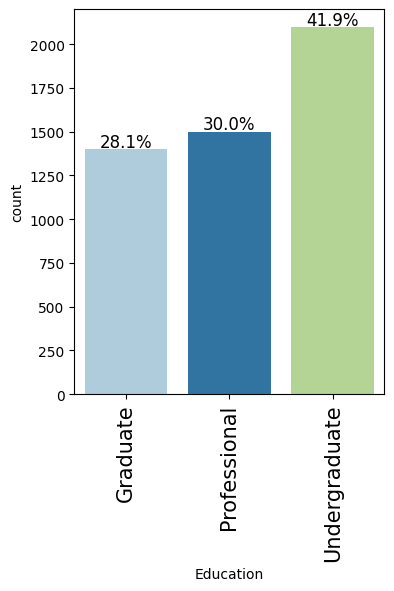

In [80]:
labeled_barplot(df, "Education", perc=True)

* Undergraduate has highest count, Graduate and Professional fewer.
* Balanced enough to compare categories.

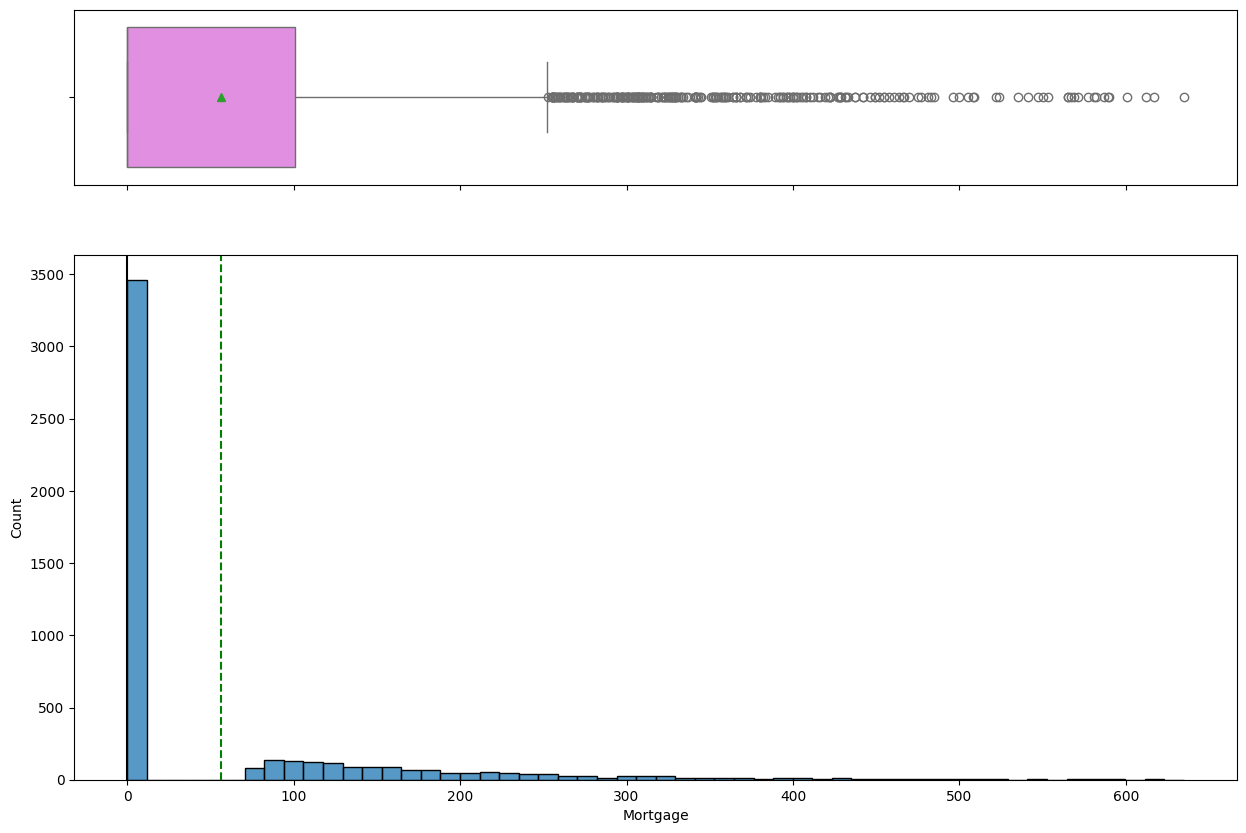

In [81]:
histogram_boxplot(df, "Mortgage")

* Large spike at 0, long right tail with some > 600.
* Most customers have no mortgage.

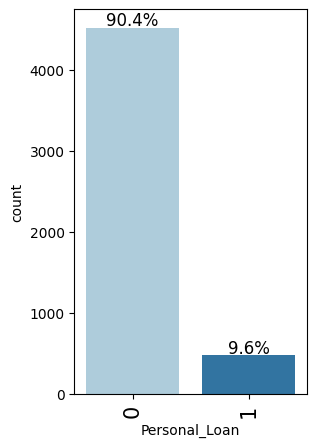

In [82]:
labeled_barplot(df, "Personal_Loan", perc=True)

* Class imbalance: ~90% no, ~10% yes.
* Confirms target is imbalanced.

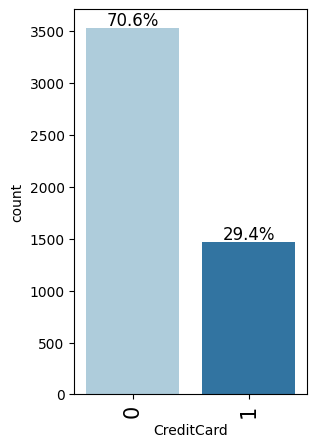

In [83]:
labeled_barplot(df, "CreditCard", perc=True)

* ~70% no credit card, ~30% yes.
* Binary feature with majority “no”.

### Bivariate Analysis

#### Correlation Check

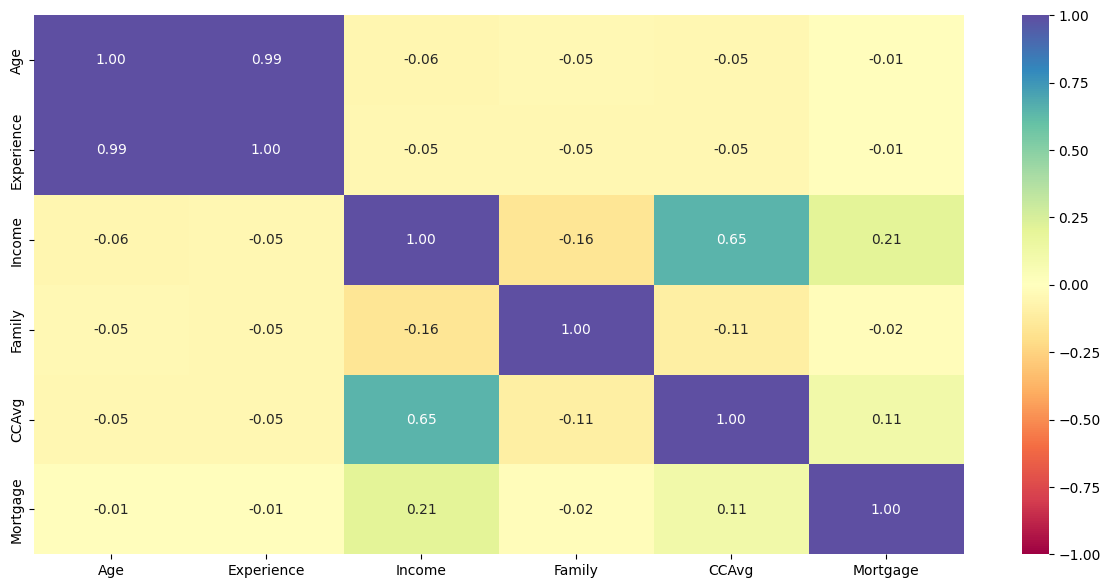

In [84]:
# Correlation Plot
plt.figure(figsize=(15, 7))
sns.heatmap(
    df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* Age and Experience show a perfect positive correlation (1.00), indicating redundancy; Income and CCAvg have a moderate positive correlation (0.59), suggesting higher income relates to higher credit spending.
* Family has a weak negative correlation with Income (-0.16), which is counterintuitive but not strong enough for significant conclusions.

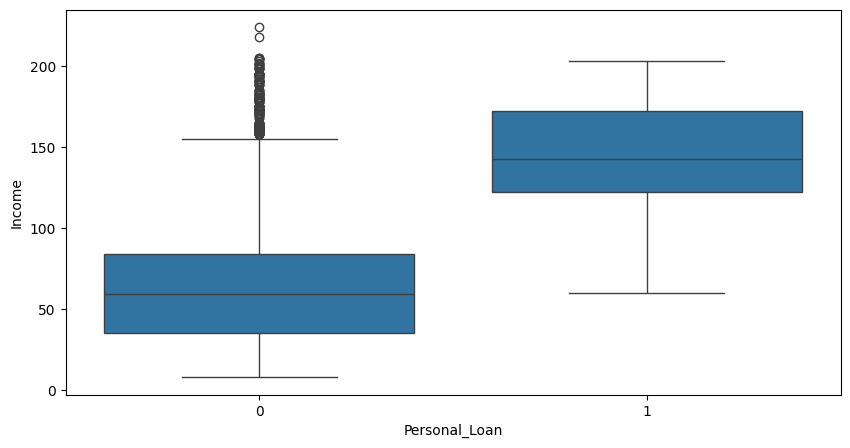

In [85]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Personal_Loan", y="Income")
plt.show()

* Customers who accepted the personal loan have significantly higher median income ($140K) compared to those who did not ($60K), indicating income is a strong predictor for loan acceptance.
* The interquartile range for loan acceptors is wider, with more high-income outliers, suggesting targeting affluent customers could improve campaign success.

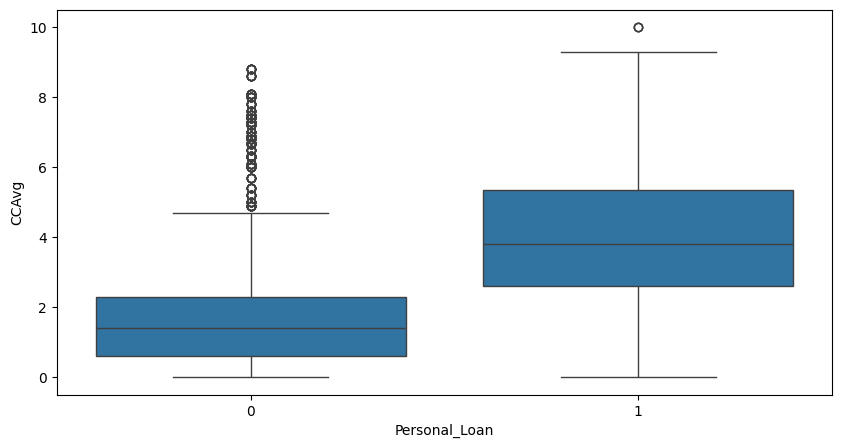

In [86]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Personal_Loan", y="CCAvg")
plt.show()

* Loan acceptors exhibit higher median credit card spending ($4K) versus non-acceptors ($1.5K), highlighting that higher spenders are more likely to take personal loans.
* Outliers in the acceptor group show extreme spending, reinforcing CCAvg as a key factor in identifying potential loan customers.

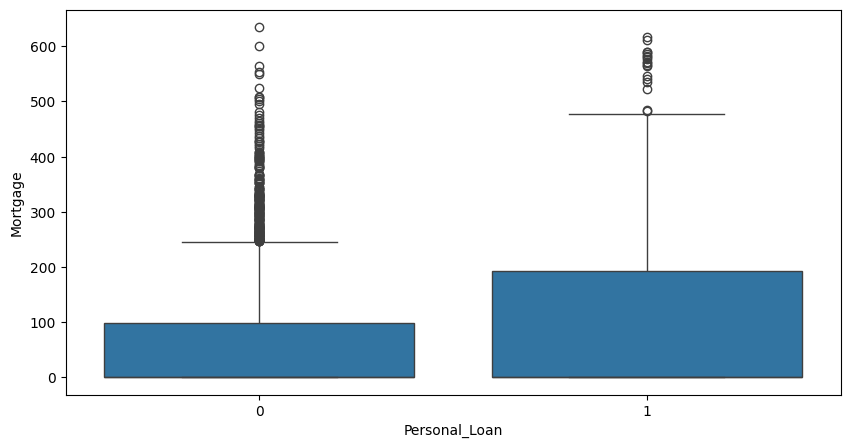

In [87]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Personal_Loan", y="Mortgage")
plt.show()

* Customers with personal loans have a higher median mortgage value ($150K) than those without ($0), suggesting mortgaged homeowners are more inclined toward additional loans.
* Many non-acceptors have zero mortgage, while acceptors show a broader range with outliers up to high values, indicating mortgage could be a secondary targeting criterion.

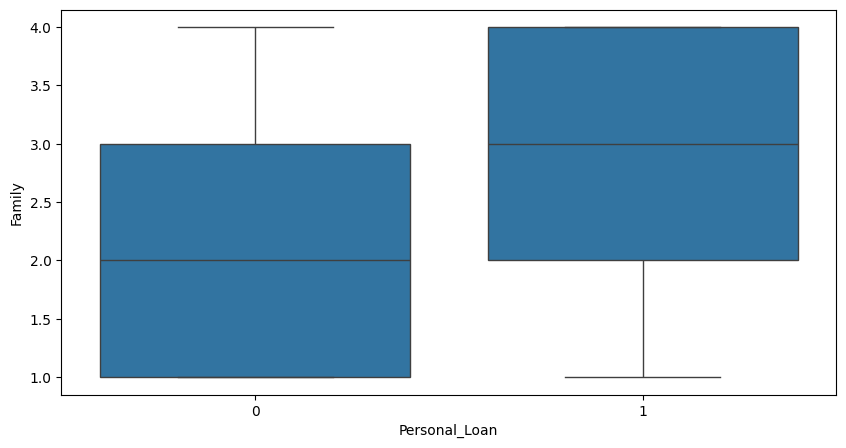

In [88]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Personal_Loan", y="Family")
plt.show()

* Loan acceptors tend to have larger family sizes (median ~3) compared to non-acceptors (median ~2), implying family needs may drive loan demand.
* The distribution shows more variability for acceptors, with families of 4+ being more common, supporting targeted campaigns for multi-member households.

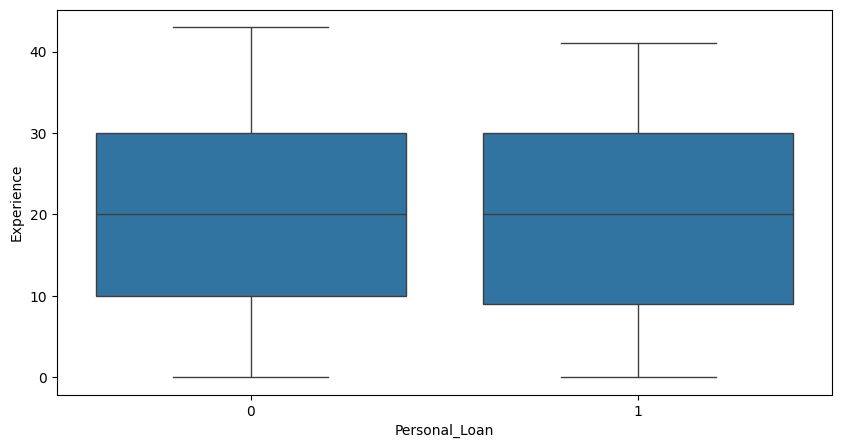

In [89]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Personal_Loan", y="Experience")
plt.show()

* Experience distributions are similar between loan acceptors and non-acceptors, with medians around 20 years, indicating experience is not a strong differentiator for loan acceptance.
* Slight overlap and comparable ranges suggest experience alone does not significantly influence the decision to take a personal loan.

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
Professional   1296  205  1501
Graduate       1221  182  1403
Undergraduate  2003   93  2096
------------------------------------------------------------------------------------------------------------------------


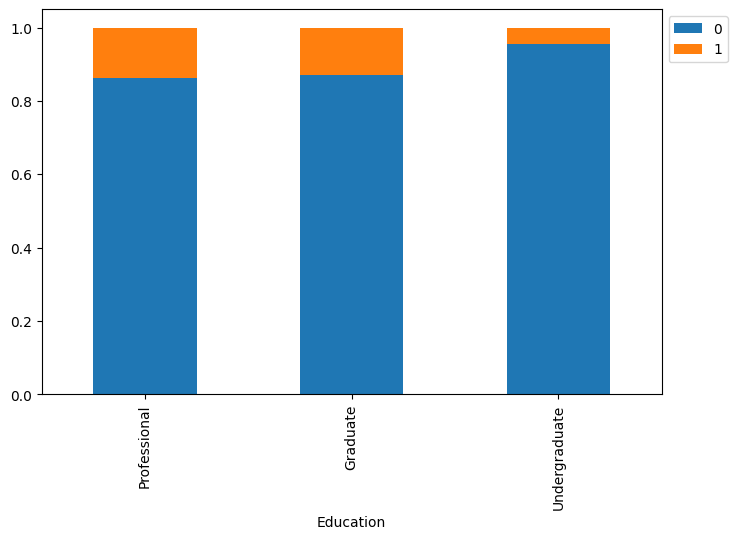

In [90]:
stacked_barplot(df, "Education", "Personal_Loan")

* Approximately 15% of customers with Professional education accepted the loan, compared to lower rates for Undergraduate (9%) and Graduate (10%), showing higher education correlates with loan interest.
* Undergraduates have the lowest acceptance rate, while Professionals and Graduates are more responsive, recommending focused marketing on advanced education segments.

#### Distribution of numerical input variables

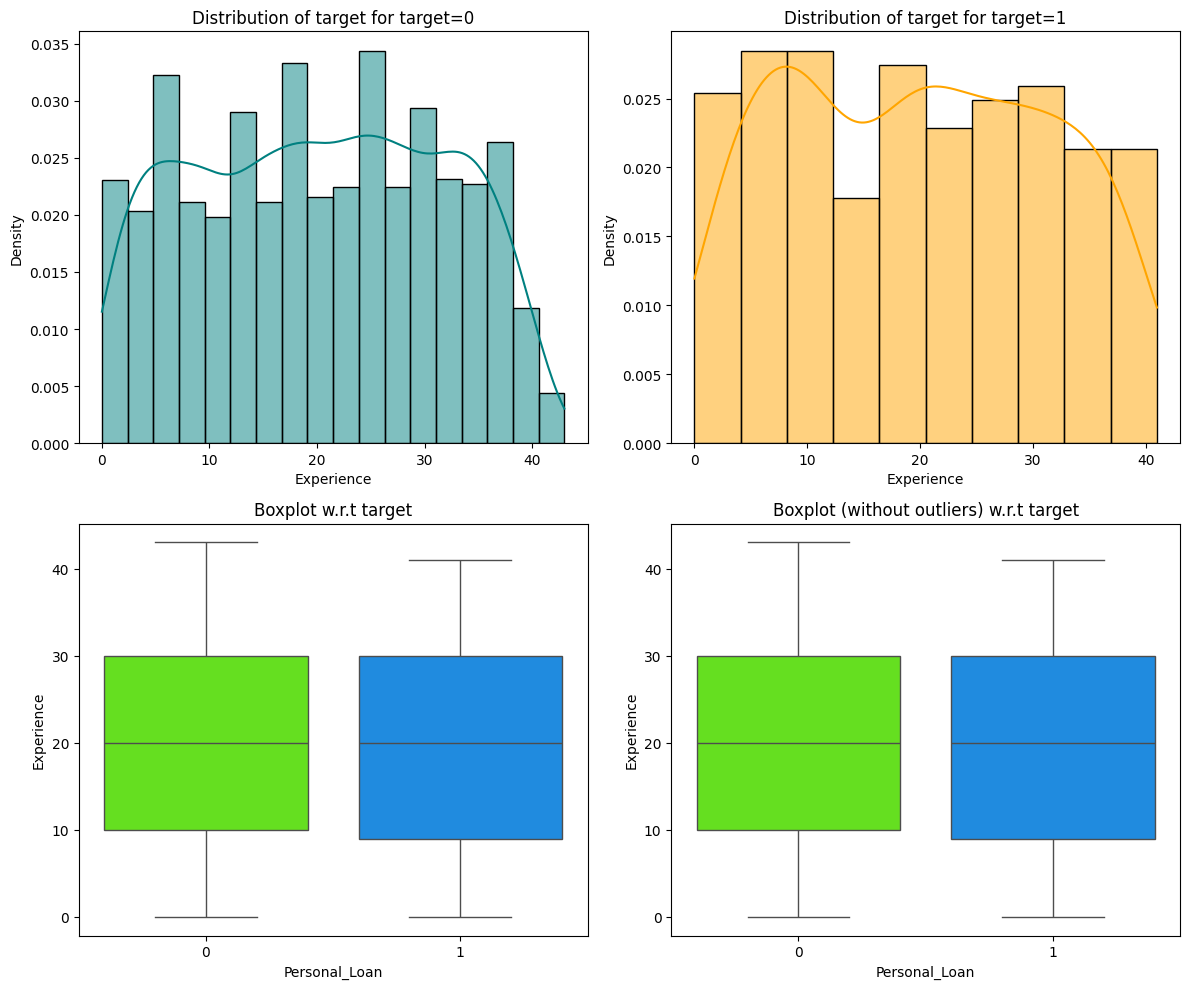

In [91]:
distribution_plot_wrt_target(df, "Experience", "Personal_Loan")

* The distributions of experience for loan acceptors and non-acceptors overlap significantly, with both showing similar ranges and densities, confirming experience is not a key predictor.
* No clear separation between classes based on experience, as both groups have comparable medians and spreads.

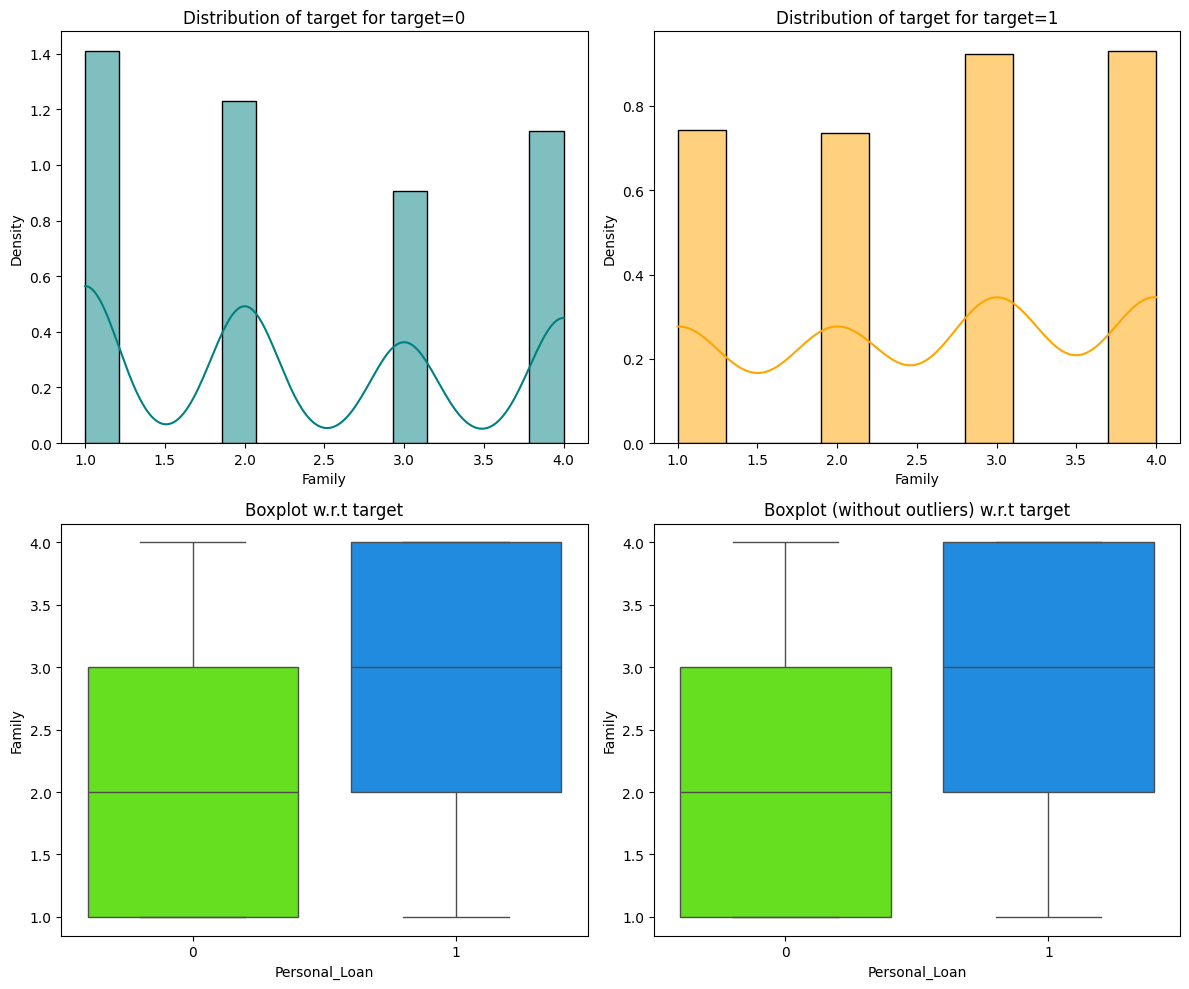

In [92]:
distribution_plot_wrt_target(df, "Family", "Personal_Loan")

* Loan acceptors show a slight shift toward larger family sizes (e.g., 3-4 members), while non-acceptors peak at smaller families (1-2), indicating family size as a moderate differentiator.
* Overlap exists, but acceptors have a broader distribution, suggesting larger families may be more likely to take loans.

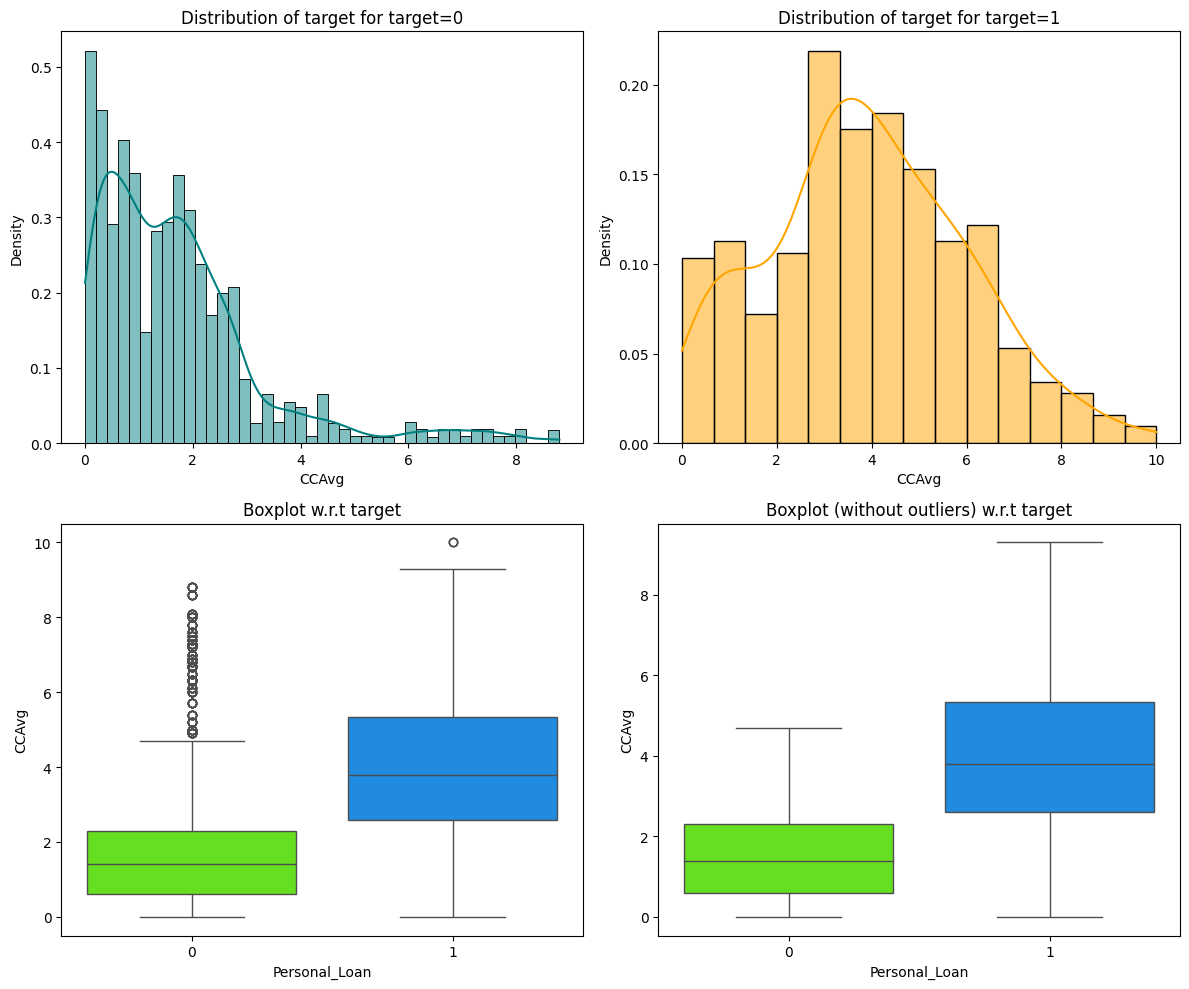

In [93]:
distribution_plot_wrt_target(df, "CCAvg", "Personal_Loan")

* Acceptors have higher CCAvg values with a right-skewed distribution peaking around 4-5, compared to non-acceptors peaking near 1-2, showing better class separation for credit spending.
* The plot highlights CCAvg as a useful feature, with acceptors generally having higher spending, though some overlap remains.

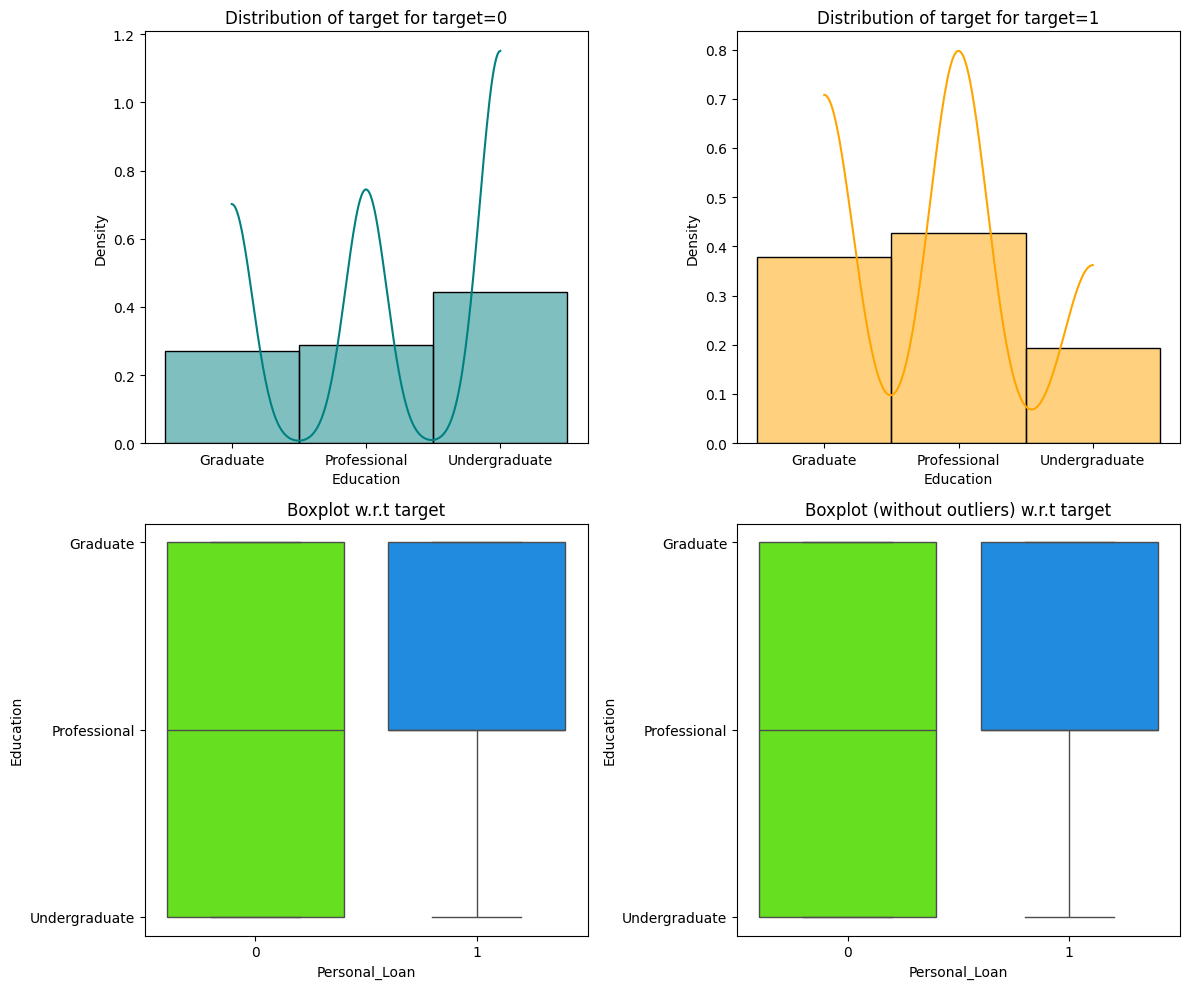

In [94]:
distribution_plot_wrt_target(df, "Education", "Personal_Loan")

* Note: Education is categorical, so the plot may not fully apply; however, it visually represents distributions, showing Professionals and Graduates more represented among acceptors.
* Reinforces that higher education levels are associated with loan acceptance, with Undergraduates less likely.

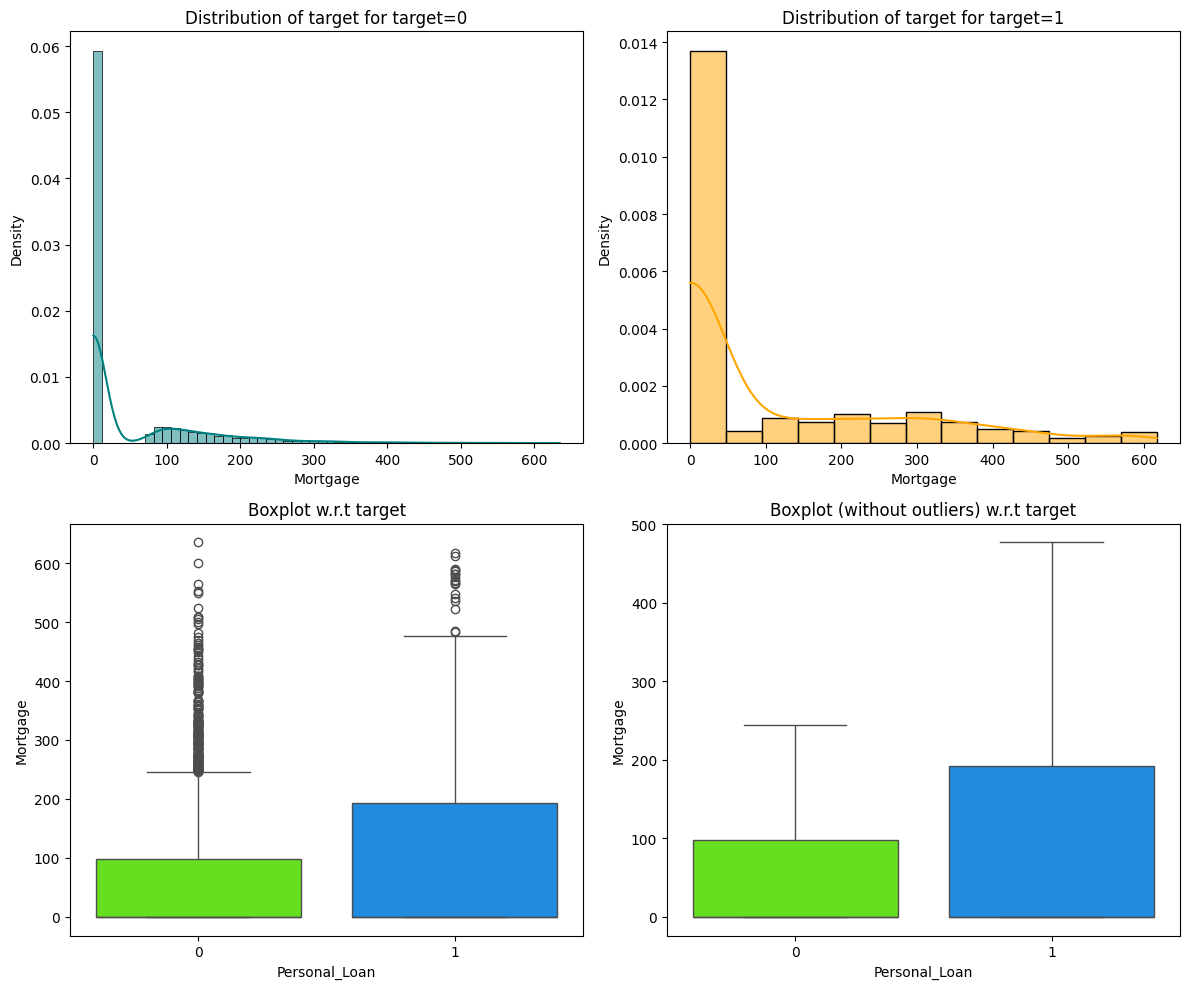

In [95]:
distribution_plot_wrt_target(df, "Mortgage", "Personal_Loan")

* Acceptors exhibit a wider range of mortgage values, including higher amounts, while non-acceptors are concentrated at zero, indicating mortgage as a potential indicator for loan interest.
* Clear separation at lower mortgage levels, with acceptors showing more variability and higher values.

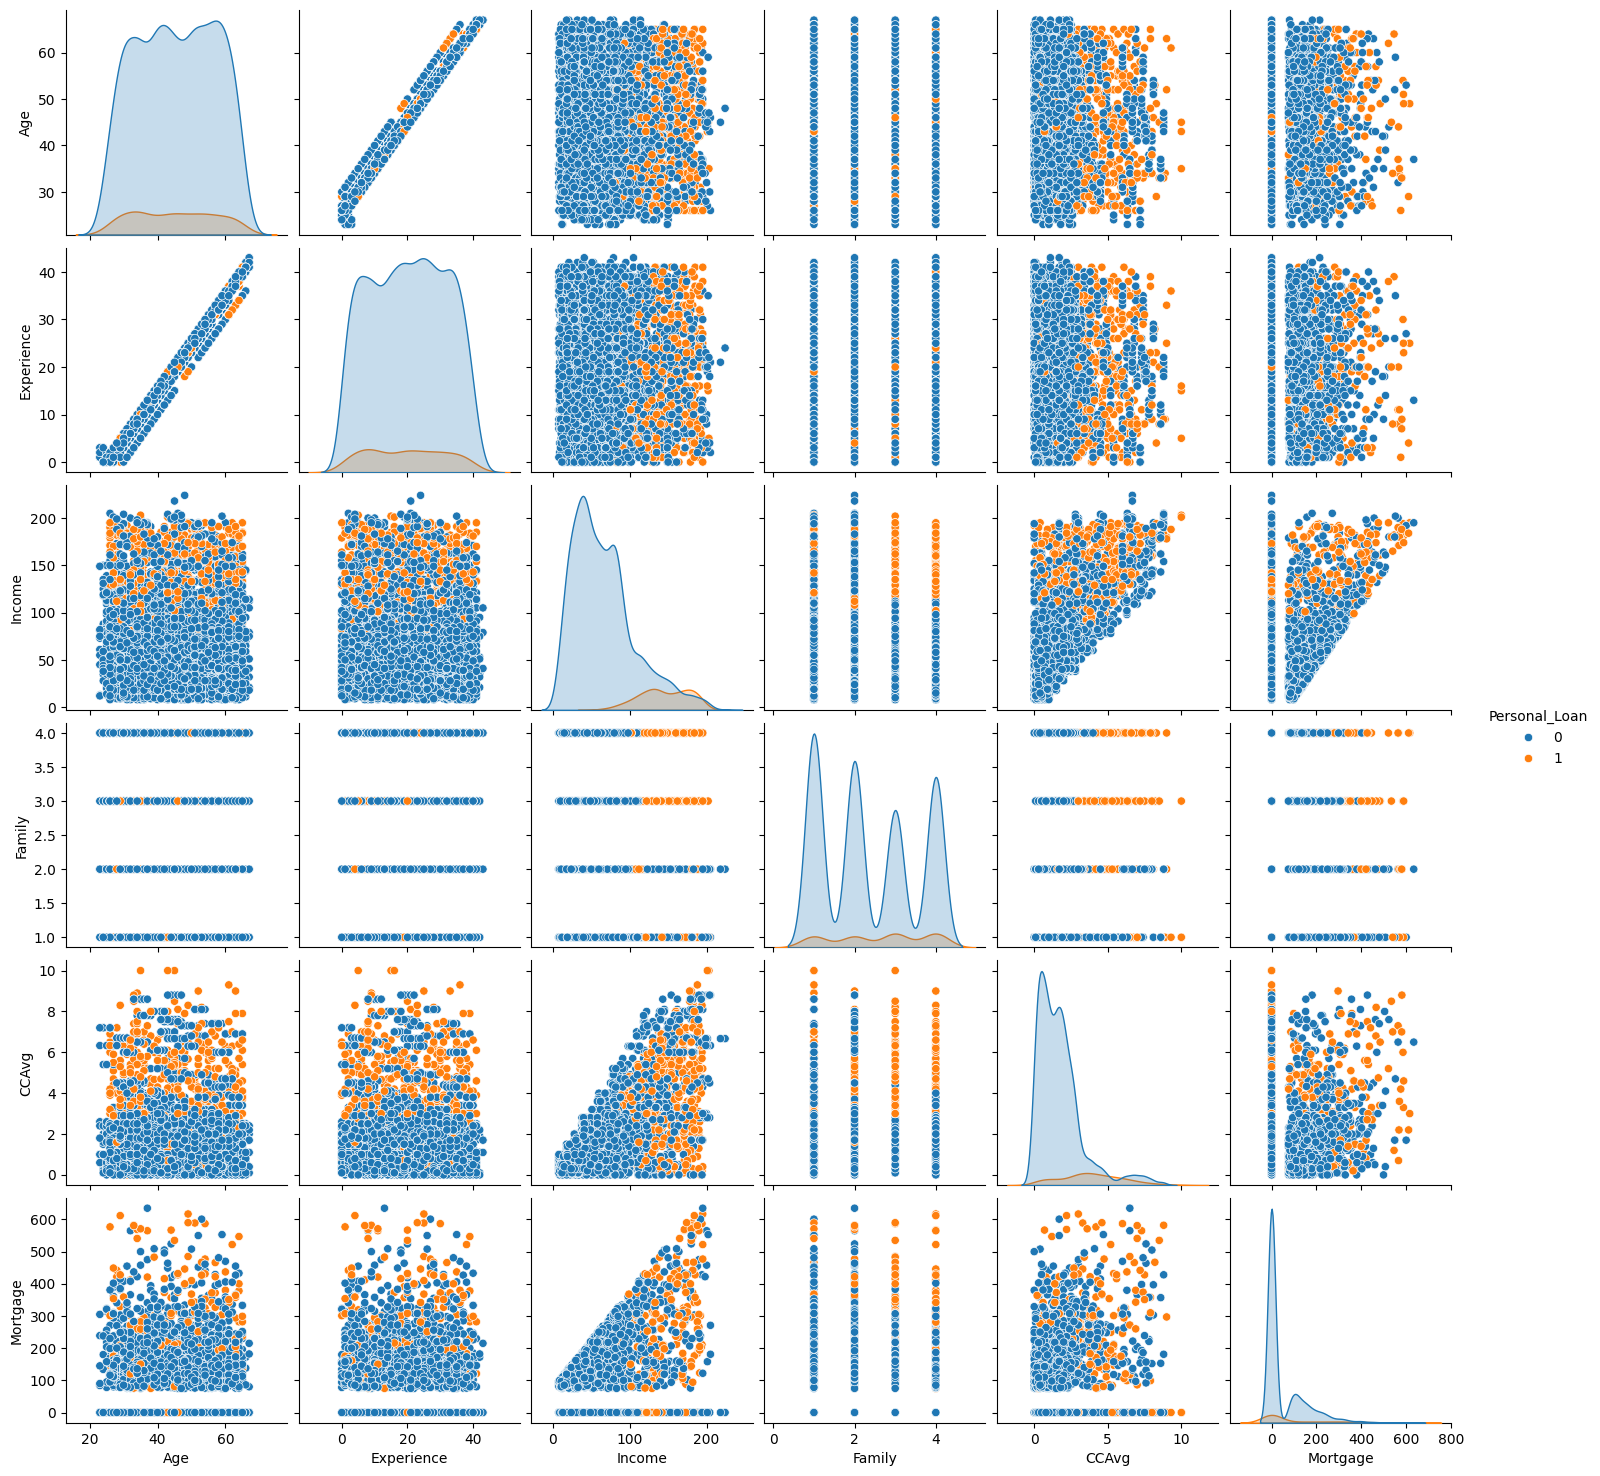

In [96]:
sns.pairplot(df, hue="Personal_Loan")

* Income/CCAvg separate classes better than others; shows overlap.
* Multivariate view confirms class imbalance and continuous predictors importance.